# Figures Generator

Runs the algorithm and then generates the figures used for the manuscript.

## Setup


In [ ]:
# Packages
display("text/html", "<style>.container { width:100% !important; }</style>")

# Julia dependencies for plotting, stats, and experiments.
using Plots, LaTeXStrings, Distributions, DoubleFloats, Plots.PlotMeasures, LinearAlgebra,
    DataFrames, CSV, LsqFit, StatsBase, Distances, Parameters, Random, StatsBase, Graphs, GraphPlot,
    Base.Threads, Printf, HypothesisTests, JLD2
# Plots.theme(:dao)

# Local modules.
include("../src/wagner_algorithm.jl")
using .BooleanNetwork
include("../src/data_processing.jl")
using .CustomStats
include("../scripts/run_experiments.jl")
using .ExperimentHandler
# include("../scripts/plot_payload.jl")
# using .PlotPayload

# Utilities.
using ProgressMeter
using Base.Threads: Atomic, atomic_add!

# Python bridge for motif search utilities.
using PyCall
py"""
import sys
import os
sys.path.append(os.path.abspath("../src/"))
from motif_search import *
"""

# STANDARD_PARAMETERS = BooleanNetwork.STANDARD_PARAMETERS;


In [1]:
# Local modules.
include("../src/wagner_algorithm.jl")
using .BooleanNetwork

In [1]:
some_vec = Vector{Float64}(undef, 5)

some_vec[2] = NaN

NaN

In [3]:
some_vec

5-element Vector{Float64}:
   1.0e-323
 NaN
   0.0
   0.0
   0.0

In [2]:
# Short aliases for type annotations.
Experiment1Config = ExperimentHandler.Experiment1Config
Experiment2Config = ExperimentHandler.Experiment2Config
Experiment1Result = ExperimentHandler.Experiment1Result
Experiment2Result = ExperimentHandler.Experiment2Result
MotifStats = ExperimentHandler.MotifStats

Main.ExperimentHandler.MotifStats

## Plotting Utilities


In [3]:
# Plotting utilities
const ROOT_DIR = normpath(joinpath(pwd(), ".."))
const FIGURES_DIR = joinpath(ROOT_DIR, "figures")
mkpath(FIGURES_DIR)
const ROBUSTNESS_FIG_DIR = joinpath(FIGURES_DIR, "scatterplots_mutational_robustness")
mkpath(ROBUSTNESS_FIG_DIR)

default(dpi=900, legendfontsize=24, guidefont=font(24), tickfont=font(24), margin=8Plots.mm, grid=false)
const BONFERRONI_TESTS = 2

"""
    save_plot(plot_obj, filename)

Save a figure to the figures directory and print the output path.
"""
function save_plot(plot_obj, filename)
    filepath = joinpath(FIGURES_DIR, filename)
    savefig(plot_obj, filepath)
    println("Saved $(filepath)")
end


save_plot

## Experiments


In [4]:
# Experiment configurations (do not change for manuscript figures).

# exp_1_config = Experiment1Config(500, 300, "stable", 30, [0.25, 0.5, 1.0, 2.0, 4.0, 8.0], 5, 30, Gamma(1.0, 1.0), 10)
exp_1_config = Experiment1Config(50, 30, "stable", 10, [1.0, 2.0], 5, 10, Gamma(1.0, 1.0), 10)
# generations, pop_size, mode, trials, thetas, robustness_n_mutations, robustness_n_noise_masks, standard_noise, n_target
exp_1_result = ExperimentHandler.run_experiment1(exp_1_config)

Experiment 1 – noise schedules 100%|█████████████████████| Time: 0:00:21


Main.ExperimentHandler.Experiment1Result(Main.ExperimentHandler.NoiseScenario[Main.ExperimentHandler.NoiseScenario("Noiseless", 0.0, Bernoulli{Float64}(p=1.0)), Main.ExperimentHandler.NoiseScenario("θ = 1.00", 1.0, Gamma{Float64}(α=1.0, θ=1.0)), Main.ExperimentHandler.NoiseScenario("θ = 2.00", 2.0, Gamma{Float64}(α=0.5, θ=2.0))], Dict(:fit => [0.01934037050899852 0.1300710776405973 … 0.9241455329405731 0.9262526014700017; 0.0038992847631206863 0.13299350992871947 … 0.8081584188154413 0.7978229181597534; 0.005654979215341754 0.16237550789760666 … 0.8655676167702865 0.8523400702671309], :path => [8.136666666666667 7.705747126436782 … 3.9599999999999995 3.9266666666666667; 7.1817673992673985 6.842758620689655 … 4.236666666666666 4.653333333333334; 5.3768939393939394 5.92183908045977 … 4.513333333333334 4.483333333333333], :completion => [0.9999999999999998 0.9933333333333334 … 1.0 1.0; 0.22333333333333333 0.99 … 1.0 1.0; 0.24666666666666667 0.9966666666666667 … 1.0 1.0], :alignment => [0.

In [5]:
# save
"""
    save_record
Saves an object of results in the experiment results file. If there is no 
key, it creates it. It over-writes the key if it exsists.
args:
    filepath: directory path
    key_name: identifier of the data
    data: experiment results object to be stored
"""
function save_record(filepath, key_name, data)
    jldopen(filepath, "a+") do file
        if haskey(file, key_name)
            delete!(file, key_name)
        end
        file[key_name] = data
    end
end
"""
    delete_record
Deletes an object of results in the experiment results file. If there is no 
key, it ignores it.
args:
    filepath: directory path
    key_name: identifier of the data
"""
function delete_record(filepath, key_name)
    jldopen(filepath, "a+") do file
        if haskey(file, key_name)
            delete!(file, key_name)
        end
    end
end

filepath = joinpath(ROOT_DIR, "notebooks", "data", "experiments_results.jld2")
key_name = """exp_1_c=$(BooleanNetwork.STANDARD_PARAMETERS["c"])_$(exp_1_config.mode)"""

save_record(filepath,key_name,exp_1_result)

Main.ExperimentHandler.Experiment1Result(Main.ExperimentHandler.NoiseScenario[Main.ExperimentHandler.NoiseScenario("Noiseless", 0.0, Bernoulli{Float64}(p=1.0)), Main.ExperimentHandler.NoiseScenario("θ = 1.00", 1.0, Gamma{Float64}(α=1.0, θ=1.0)), Main.ExperimentHandler.NoiseScenario("θ = 2.00", 2.0, Gamma{Float64}(α=0.5, θ=2.0))], Dict(:fit => [0.01934037050899852 0.1300710776405973 … 0.9241455329405731 0.9262526014700017; 0.0038992847631206863 0.13299350992871947 … 0.8081584188154413 0.7978229181597534; 0.005654979215341754 0.16237550789760666 … 0.8655676167702865 0.8523400702671309], :path => [8.136666666666667 7.705747126436782 … 3.9599999999999995 3.9266666666666667; 7.1817673992673985 6.842758620689655 … 4.236666666666666 4.653333333333334; 5.3768939393939394 5.92183908045977 … 4.513333333333334 4.483333333333333], :completion => [0.9999999999999998 0.9933333333333334 … 1.0 1.0; 0.22333333333333333 0.99 … 1.0 1.0; 0.24666666666666667 0.9966666666666667 … 1.0 1.0], :alignment => [0.

In [6]:
# load data
exp_1_result = load(joinpath(ROOT_DIR, "notebooks", "data", "experiments_results.jld2"), "exp_1_c=1.0_stable")

Main.ExperimentHandler.Experiment1Result(Main.ExperimentHandler.NoiseScenario[Main.ExperimentHandler.NoiseScenario("Noiseless", 0.0, Bernoulli{Float64}(p=1.0)), Main.ExperimentHandler.NoiseScenario("θ = 1.00", 1.0, Gamma{Float64}(α=1.0, θ=1.0)), Main.ExperimentHandler.NoiseScenario("θ = 2.00", 2.0, Gamma{Float64}(α=0.5, θ=2.0))], Dict(:fit => [0.01934037050899852 0.1300710776405973 … 0.9241455329405731 0.9262526014700017; 0.0038992847631206863 0.13299350992871947 … 0.8081584188154413 0.7978229181597534; 0.005654979215341754 0.16237550789760666 … 0.8655676167702865 0.8523400702671309], :path => [8.136666666666667 7.705747126436782 … 3.9599999999999995 3.9266666666666667; 7.1817673992673985 6.842758620689655 … 4.236666666666666 4.653333333333334; 5.3768939393939394 5.92183908045977 … 4.513333333333334 4.483333333333333], :completion => [0.9999999999999998 0.9933333333333334 … 1.0 1.0; 0.22333333333333333 0.99 … 1.0 1.0; 0.24666666666666667 0.9966666666666667 … 1.0 1.0], :alignment => [0.

In [7]:
base_params = deepcopy(BooleanNetwork.STANDARD_PARAMETERS)
base_params["G"] = exp_1_config.generations
base_params["pop_size"] = exp_1_config.pop_size
base_params["mode"] = exp_1_config.mode

# exp_2_config = Experiment2Config(30, 5, 30)
exp_2_config = Experiment2Config(3, 5, 10)
# trials, max_loop_size, sample_size
noise_scenarios = ExperimentHandler.build_noise_scenarios(exp_1_config)
exp_2_result = ExperimentHandler.run_experiment2(exp_2_config, base_params, noise_scenarios)


Random matrices 100%|████████████████████████████████████| Time: 0:00:10
Noiseless evolution 100%|████████████████████████████████| Time: 0:00:08
High-noise evolution 100%|███████████████████████████████| Time: 0:00:09


Main.ExperimentHandler.Experiment2Result(Main.ExperimentHandler.MotifStats(Dict("Incoherent Type 3 (I3)" => [0.12083333333333332, 0.1275, 0.12319444444444443], "Coherent Type 2 (C2)" => [0.1288888888888889, 0.11708333333333332, 0.13513888888888886], "Incoherent Type 2 (I2)" => [0.12194444444444445, 0.13361111111111112, 0.11680555555555557], "Coherent Type 1 (C1)" => [0.11805555555555554, 0.14333333333333334, 0.1201388888888889], "Incoherent Type 4 (I4)" => [0.12333333333333334, 0.10263888888888888, 0.12375], "Coherent Type 3 (C3)" => [0.13, 0.12319444444444443, 0.12874999999999998], "Incoherent Type 1 (I1)" => [0.12444444444444444, 0.13152777777777777, 0.12013888888888888], "Coherent Type 4 (C4)" => [0.1325, 0.1211111111111111, 0.13208333333333333]), Dict(5 => [0.5003968253968254, 0.5017195767195768, 0.4978835978835979], 4 => [0.49857142857142855, 0.5001587301587301, 0.5046031746031746], 2 => [0.5244444444444445, 0.5222222222222221, 0.5755555555555555], 3 => [0.51, 0.48916666666666664,

In [8]:
# save
key_2_name = """exp_2_c=$(BooleanNetwork.STANDARD_PARAMETERS["c"])_stable"""
save_record(filepath, key_2_name, exp_2_result)

Main.ExperimentHandler.Experiment2Result(Main.ExperimentHandler.MotifStats(Dict("Incoherent Type 3 (I3)" => [0.12083333333333332, 0.1275, 0.12319444444444443], "Coherent Type 2 (C2)" => [0.1288888888888889, 0.11708333333333332, 0.13513888888888886], "Incoherent Type 2 (I2)" => [0.12194444444444445, 0.13361111111111112, 0.11680555555555557], "Coherent Type 1 (C1)" => [0.11805555555555554, 0.14333333333333334, 0.1201388888888889], "Incoherent Type 4 (I4)" => [0.12333333333333334, 0.10263888888888888, 0.12375], "Coherent Type 3 (C3)" => [0.13, 0.12319444444444443, 0.12874999999999998], "Incoherent Type 1 (I1)" => [0.12444444444444444, 0.13152777777777777, 0.12013888888888888], "Coherent Type 4 (C4)" => [0.1325, 0.1211111111111111, 0.13208333333333333]), Dict(5 => [0.5003968253968254, 0.5017195767195768, 0.4978835978835979], 4 => [0.49857142857142855, 0.5001587301587301, 0.5046031746031746], 2 => [0.5244444444444445, 0.5222222222222221, 0.5755555555555555], 3 => [0.51, 0.48916666666666664,

In [9]:
exp_2_result = load(joinpath(ROOT_DIR, "notebooks", "data", "experiments_results.jld2"), "exp_2_c=1.0_stable")

Main.ExperimentHandler.Experiment2Result(Main.ExperimentHandler.MotifStats(Dict("Incoherent Type 3 (I3)" => [0.12083333333333332, 0.1275, 0.12319444444444443], "Coherent Type 2 (C2)" => [0.1288888888888889, 0.11708333333333332, 0.13513888888888886], "Incoherent Type 2 (I2)" => [0.12194444444444445, 0.13361111111111112, 0.11680555555555557], "Coherent Type 1 (C1)" => [0.11805555555555554, 0.14333333333333334, 0.1201388888888889], "Incoherent Type 4 (I4)" => [0.12333333333333334, 0.10263888888888888, 0.12375], "Coherent Type 3 (C3)" => [0.13, 0.12319444444444443, 0.12874999999999998], "Incoherent Type 1 (I1)" => [0.12444444444444444, 0.13152777777777777, 0.12013888888888888], "Coherent Type 4 (C4)" => [0.1325, 0.1211111111111111, 0.13208333333333333]), Dict(5 => [0.5003968253968254, 0.5017195767195768, 0.4978835978835979], 4 => [0.49857142857142855, 0.5001587301587301, 0.5046031746031746], 2 => [0.5244444444444445, 0.5222222222222221, 0.5755555555555555], 3 => [0.51, 0.48916666666666664,


# Experiment 1: Time-Series Metrics


In [10]:
"""
    add_variance_colorbar!(plt, scenarios, colorscheme)

Add a variance colorbar for noisy scenarios.
"""
function add_variance_colorbar!(plt, scenarios, colorscheme)
    if isempty(scenarios)
        return
    end
    min_v = minimum(s.variance for s in scenarios)
    max_v = maximum(s.variance for s in scenarios)
    plot!(
        plt,
        0:1,
        fill(NaN, 2);
        zcolor=[min_v, max_v],
        c=colorscheme,
        label="",
        colorbar=true,
        colorbar_title="Noise Variance " * L"(\theta)",
        grid=false,
        fontsize=12,
        colorbar_titlefont=12,
        colorbar_width=4,
        dpi = 600,
    )
end
"""
    plot_metric_many_trials(result::Experiment1Result, metric_key::Symbol;
                            xlabel="Generation", ylabel="", colorscheme=cgrad(:blues),
                            init_gen=1, title="", ci_mult=1.96, outfile=nothing)

Plots `result.averages[metric_key]` with ribbons from `result.sems[metric_key]`.
- Row 1 = baseline scenario (black dotted line)
- Rows 2:end = noisy scenarios, colored by scenario.variance + colorbar
- If `outfile` is provided, saves the plot.
Returns the plot object.
"""
function plot_metric_many_trials(result::Experiment1Result, metric_key::Symbol;
    xlabel::AbstractString="Generation",
    ylabel::AbstractString="",
    colorscheme=cgrad(:blues),
    init_gen::Int=1,
    title::AbstractString="",
    ci_mult::Real=1.96,
    outfile::Union{Nothing,AbstractString}=nothing,
    variance_colorbar::Bool=true,)

    max_gens = result.config.generations
    scenarios = result.scenarios

    # Fetch metric matrices from dicts.
    metric_avgs = result.averages[metric_key]
    metric_sems = result.sems[metric_key]

    gens = init_gen:max_gens

    # Baseline (scenario 1).
    plt = plot(
        1:max_gens,
        metric_avgs[1, 1:max_gens];
        ribbon=metric_sems[1, 1:max_gens],
        color=:black,
        linestyle=:dot,
        linewidth=2,
        label=scenarios[1].label,
        xlabel=xlabel,
        ylabel=ylabel,
        title=title,
        grid=false,
        xgrid=false,
        ygrid=false,
        minorgrid=false,
        legend=:best,
        size=(600, 400),
        fontsize = 12,
        legendfontsize = 12,
        tickfontsize= 12,
        margins = 5Plots.mm,
        dpi = 600,
    )

    # Noisy scenarios (2:end), colored by variance.
    noisy_scenarios = scenarios[2:end]
    if !isempty(noisy_scenarios)
        min_var = minimum(s.variance for s in noisy_scenarios)
        max_var = maximum(s.variance for s in noisy_scenarios)
        denom = max(max_var - min_var, eps())

        for (offset, scenario) in enumerate(noisy_scenarios)
            rel_idx = offset + 1
            norm_v = (scenario.variance - min_var) / denom
            line_color = get(colorscheme, clamp(norm_v, 0.0, 1.0))

            plot!(
                plt,
                gens,
                metric_avgs[rel_idx, init_gen:max_gens];
                ribbon=metric_sems[rel_idx, init_gen:max_gens] .* ci_mult,
                color=line_color,
                linewidth=2,
                label=(rel_idx == 2 ? "Noisy" : ""),
                grid=false,
                xgrid=false,
                ygrid=false,
                minorgrid=false,
            )
        end
        if variance_colorbar
            add_variance_colorbar!(plt, noisy_scenarios, colorscheme)
        end
    end

    if outfile !== nothing
        save_plot(plt, outfile)
    end

    return plt
end

using Plots

"""
    add_zoom_inset!(
        plt,
        result::Experiment1Result,
        metric_key::Symbol;
        xzoom::Tuple{<:Real,<:Real},
        yzoom::Union{Nothing,Tuple{<:Real,<:Real}}=nothing,
        inset_bbox=(0.70, 0.18, 0.28, 0.72),   # (x, y, w, h) in relative figure coords
        inset_title="Zoom near steady state",
        colorscheme=cgrad(:blues),
        init_gen::Int=1,
        ci_mult::Real=1.96,
        rect_lw::Real=2,
        rect_lc=:black,
        rect_ls=:dash,
    )

Adds a zoomed inset *inside* `plt` and draws a rectangle on the main axes marking the zoom region.

Assumes `plt` is the plot returned by `plot_metric_many_trials(result, metric_key; ...)`.
"""
function add_zoom_inset!(
    plt,
    result::Experiment1Result,
    metric_key::Symbol;
    xzoom::Tuple{<:Real,<:Real},
    yzoom::Union{Nothing,Tuple{<:Real,<:Real}}=nothing,
    inset_bbox=(0.70, 0.18, 0.28, 0.72),
    inset_title::AbstractString="Zoom near steady state",
    colorscheme=cgrad(:blues),
    init_gen::Int=1,
    ci_mult::Real=1.96,
    rect_lw::Real=2,
    rect_lc=:black,
    rect_ls=:dash,
)
    max_gens  = result.config.generations
    scenarios = result.scenarios

    metric_avgs = result.averages[metric_key]
    metric_sems = result.sems[metric_key] / 1.96

    # -------------------------
    # 1) Draw rectangle on main plot
    # -------------------------
    x1, x2 = xzoom
    if yzoom === nothing
        # If yzoom not provided, infer from plotted data within xzoom across all scenarios
        g1 = max(init_gen, Int(floor(x1)))
        g2 = min(max_gens, Int(ceil(x2)))
        ys = vec(metric_avgs[:, g1:g2])
        # pad a little
        ypad = 0.05 * (maximum(ys) - minimum(ys) + eps())
        y1 = minimum(ys) - ypad
        y2 = maximum(ys) + ypad
    else
        y1, y2 = yzoom
    end

    rect = Shape([x1, x2, x2, x1], [y1, y1, y2, y2])
    plot!(plt, rect; c=:transparent, lc=rect_lc, lw=rect_lw, ls=rect_ls, label="")

    # -------------------------
    # 2) Create an inset subplot region
    # -------------------------
    plot!(plt; inset=(1, bbox(inset_bbox...)))  # creates subplot=2 inside subplot=1

    # -------------------------
    # 3) Re-plot the same series into the inset (subplot=2), with zoomed limits
    # -------------------------
    gens = init_gen:max_gens

    # Baseline
    plot!(
        plt,
        1:max_gens,
        metric_avgs[1, 1:max_gens];
        ribbon=metric_sems[1, 1:max_gens] .* ci_mult,
        color=:black,
        linestyle=:dot,
        linewidth=2,
        label="",
        subplot=2,
        xlims=(x1, x2),
        ylims=(y1, y2),
        title=inset_title,
        grid=false,
        xgrid=false,
        ygrid=false,
        minorgrid=false,
        legend=false,
        fontsize=10,
        tickfontsize=10,
    )

    # Noisy scenarios 
    noisy_scenarios = scenarios[2:end]
    if !isempty(noisy_scenarios)
        min_var = minimum(s.variance for s in noisy_scenarios)
        max_var = maximum(s.variance for s in noisy_scenarios)
        denom = max(max_var - min_var, eps())

        for (offset, scenario) in enumerate(noisy_scenarios)
            rel_idx = offset + 1
            norm_v = (scenario.variance - min_var) / denom
            line_color = get(colorscheme, clamp(norm_v, 0.0, 1.0))

            plot!(
                plt,
                gens,
                metric_avgs[rel_idx, init_gen:max_gens];
                ribbon=metric_sems[rel_idx, init_gen:max_gens] .* ci_mult,
                color=line_color,
                linewidth=2,
                label="",
                subplot=2,
            )
        end
    end

    return plt
end


add_zoom_inset!

### Figure 3: Fitness and Path Length


Saved c:\Users\Kichi\Documents\Documentos_and_Stuff\Academic Projects\SFI GRNs\WagnerNoiseExtension\wagner-noise-extension\figures\fitness_evolution_stable.png


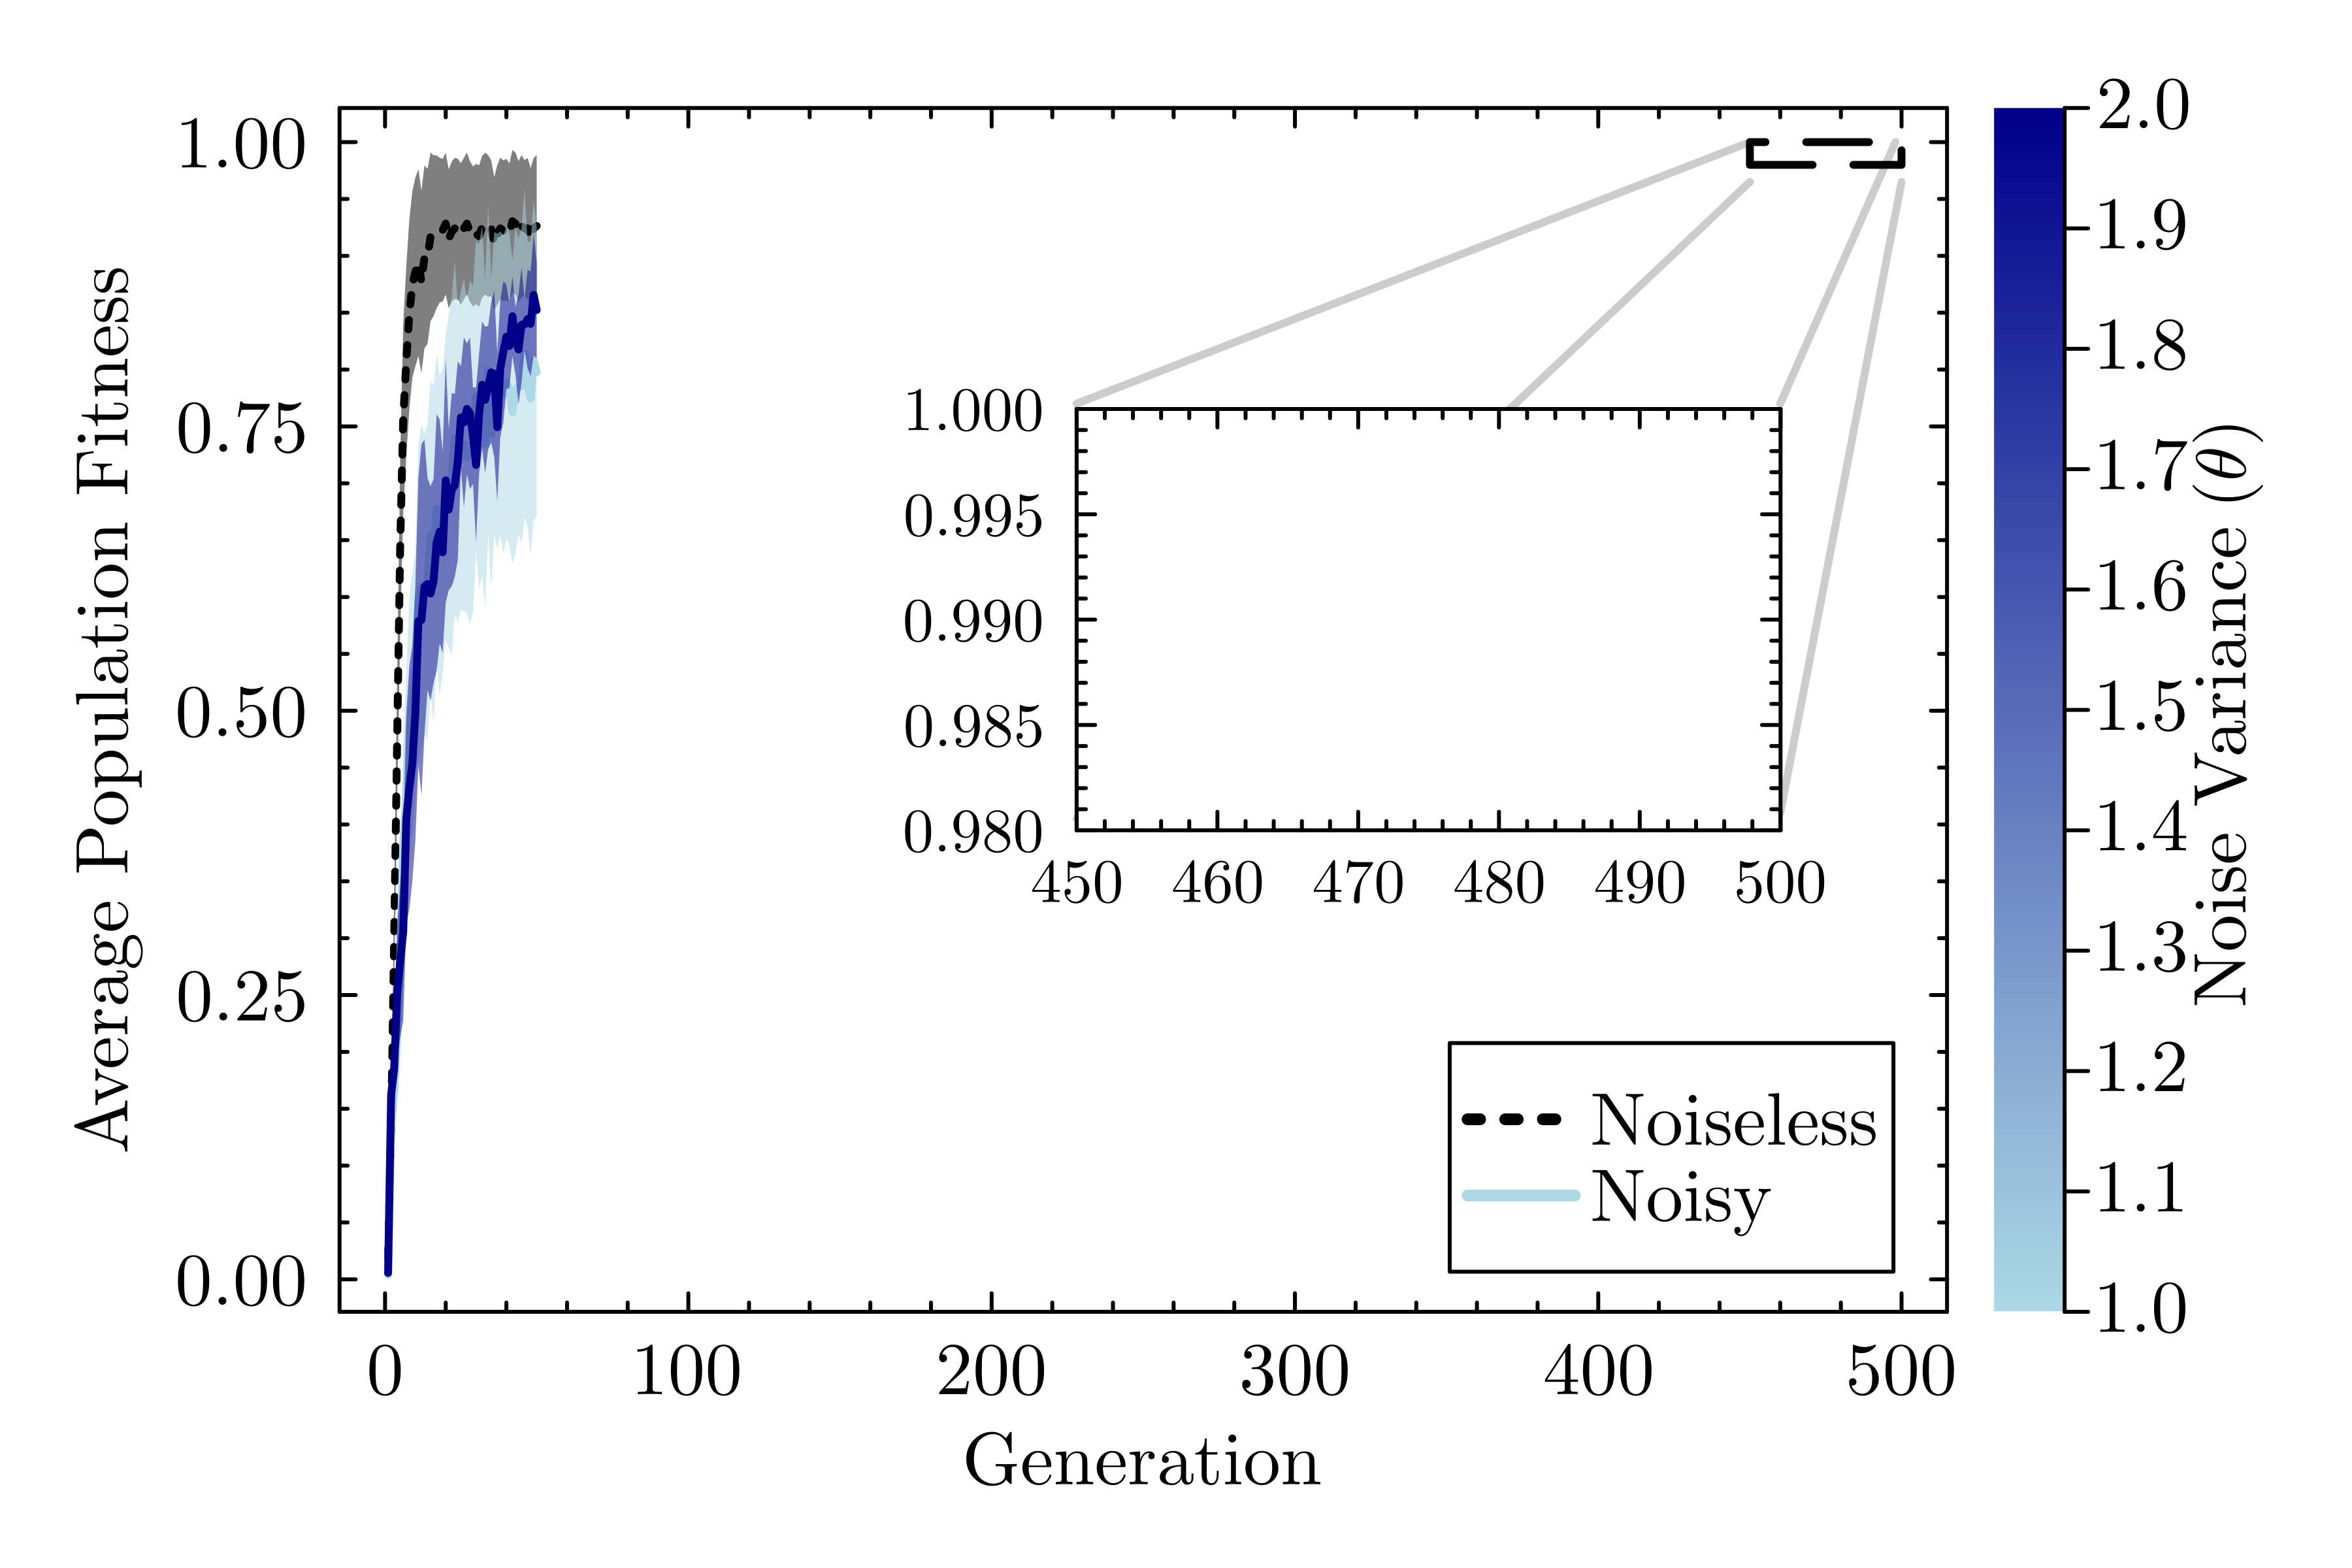

Saved c:\Users\Kichi\Documents\Documentos_and_Stuff\Academic Projects\SFI GRNs\WagnerNoiseExtension\wagner-noise-extension\figures\fitness_evolution_stable.png


In [11]:
mode_tag = lowercase(replace(exp_1_result.config.mode, " " => "_"))

Plots.theme(:dao)

# Figure 3: fitness and path length time series.
plot_avg_fitness = plot_metric_many_trials(exp_1_result, :fit;
    ylabel="Average Population Fitness", outfile="fitness_evolution_$(mode_tag).png", colorscheme=cgrad(:blues), variance_colorbar = false)

add_zoom_inset!(plot_avg_fitness, exp_1_result, :fit; xzoom=(450, 500),yzoom = (0.98,1.00), inset_bbox=(0.4, 0.25, 0.382, 0.35), inset_title="")  # yzoom auto

plot!([228, 450], [0.77, 1.0], linewidth=2, color=:black, label="", alpha=0.2)
plot!([228, 450], [0.405, 0.965], linewidth=2, color=:black, label="", alpha=0.2)
plot!([460, 498], [0.77, 1.0], linewidth=2, color=:black, label="", alpha=0.2)
plot!([460, 500], [0.41, 0.965], linewidth=2, color=:black, label="", alpha = 0.2)

exp_1_scenarios = exp_1_result.scenarios[2:end]
add_variance_colorbar!(plot_avg_fitness, exp_1_scenarios, cgrad(:blues))

display(plot_avg_fitness)

save_plot(plot_avg_fitness, "fitness_evolution_$(mode_tag).png")


Saved c:\Users\Kichi\Documents\Documentos_and_Stuff\Academic Projects\SFI GRNs\WagnerNoiseExtension\wagner-noise-extension\figures\path_evolution_stable.png
Initial Average = 8.14

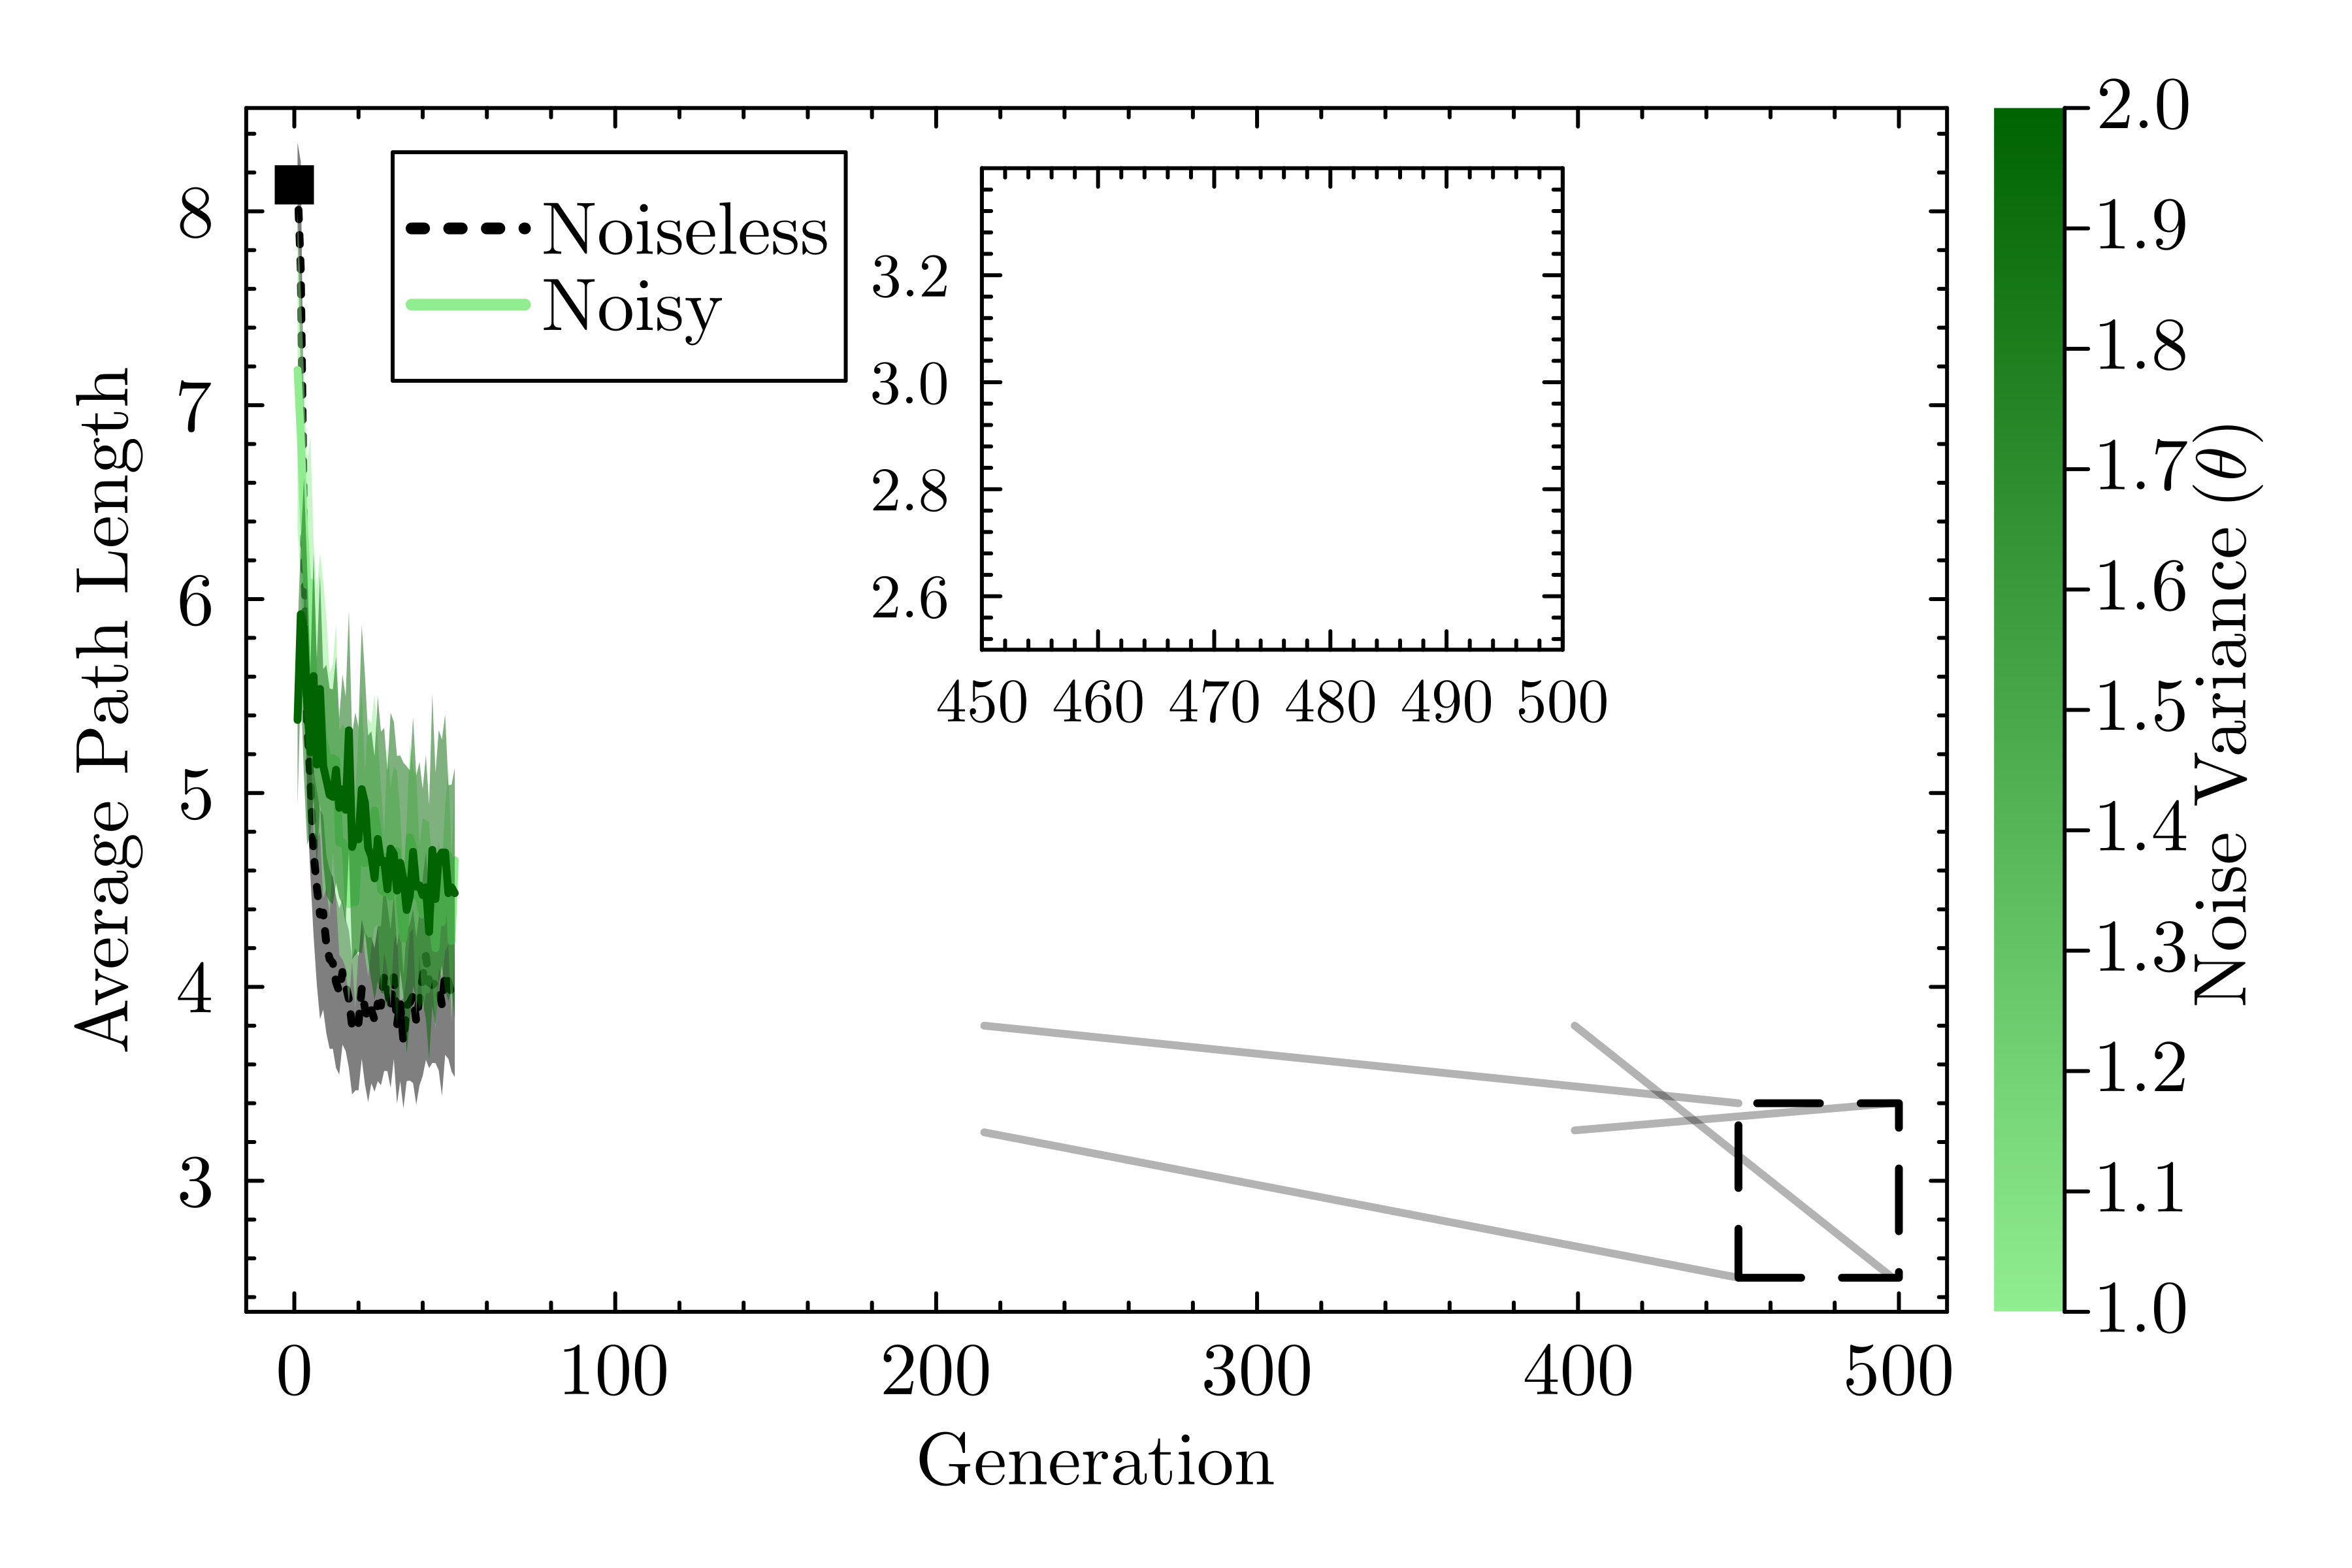

Saved c:\Users\Kichi\Documents\Documentos_and_Stuff\Academic Projects\SFI GRNs\WagnerNoiseExtension\wagner-noise-extension\figures\path_evolution_stable.png


In [12]:
plot_avg_path = plot_metric_many_trials(exp_1_result, :path;
    ylabel="Average Path Length", outfile="path_evolution_$(mode_tag).png", colorscheme=cgrad(:greens),variance_colorbar = false)

add_zoom_inset!(plot_avg_path, exp_1_result, :path; xzoom=(450, 500), yzoom=(2.5, 3.4), inset_bbox=(0.38, 0.05, 0.30, 0.40), inset_title="", colorscheme=cgrad(:greens))  # yzoom auto
plot!(plot_avg_path, legend=(0.175, 0.9))
plot!([215, 450], [3.8, 3.4], linewidth=2, color=:black, label="", alpha=0.3)
plot!([215, 450], [3.25, 2.5], linewidth=2, color=:black, label="", alpha=0.3)
plot!([399, 498], [3.26, 3.4], linewidth=2, color=:black, label="", alpha=0.3)
plot!([399, 498], [3.8, 2.5], linewidth=2, color=:black, label="", alpha=0.3)
scatter!([0], [exp_1_result.averages[:path][1]], label="", color =:black, markershape=:rect, markersize = 5)
print("Initial Average = $(round((exp_1_result.averages[:path][1]),digits=2))")

# 2.8, 4.6
# 5.2, 8.0
exp_1_scenarios = exp_1_result.scenarios[2:end]
add_variance_colorbar!(plot_avg_path, exp_1_scenarios, cgrad(:greens))

display(plot_avg_path)

save_plot(plot_avg_path, "path_evolution_$(mode_tag).png")
    

Saved c:\Users\Kichi\Documents\Documentos_and_Stuff\Academic Projects\SFI GRNs\WagnerNoiseExtension\wagner-noise-extension\figures\completion_evolution_stable.png
Saved c:\Users\Kichi\Documents\Documentos_and_Stuff\Academic Projects\SFI GRNs\WagnerNoiseExtension\wagner-noise-extension\figures\alignment_evolution_stable.png


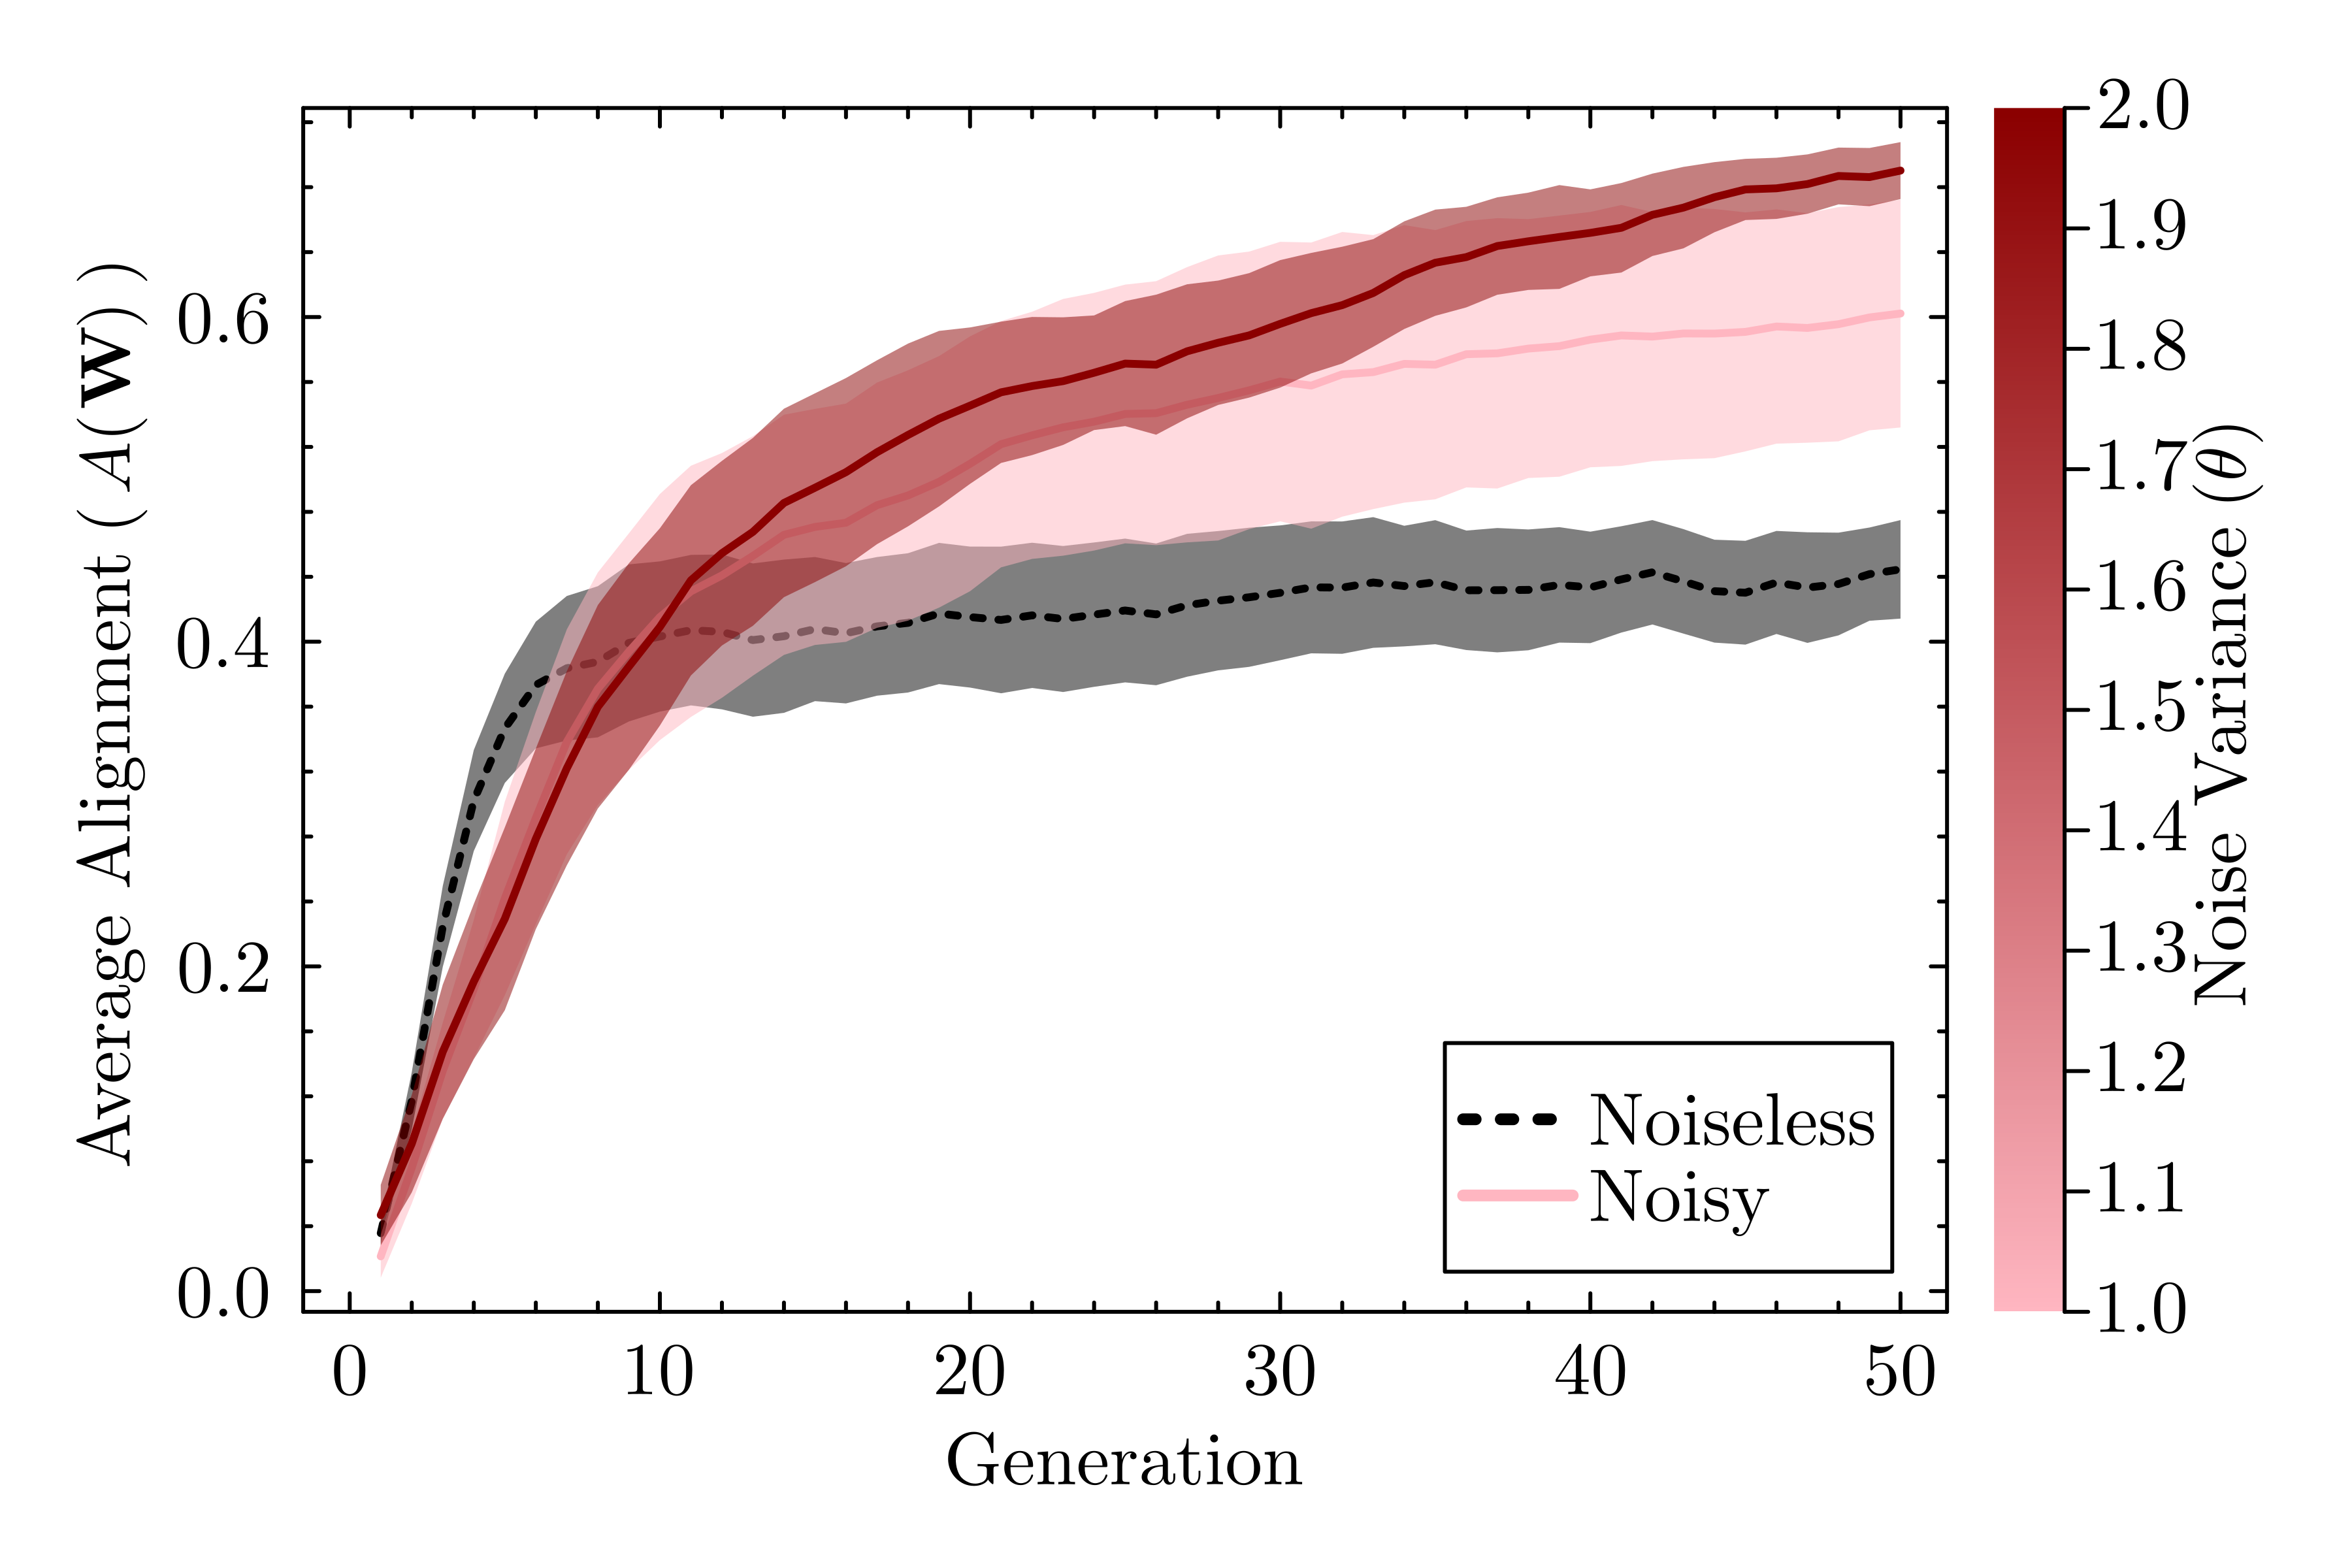

In [13]:
plot_avg_completion = plot_metric_many_trials(exp_1_result, :completion;
    ylabel="Average Completion", outfile="completion_evolution_$(mode_tag).png", colorscheme=cgrad(:Purples_8))
plot_avg_alignment = plot_metric_many_trials(exp_1_result, :alignment;
    ylabel="Average Alignment " * L"\left(A (𝐖) \,\right)", outfile="alignment_evolution_$(mode_tag).png", colorscheme=cgrad(:reds))


### Figure 4: Alignment Analysis


In [14]:
"""
    alignment_scatter_plot(result::Experiment1Result)

Create the final alignment vs noise scatter plot with a broken x-axis.
"""
function alignment_scatter_plot(result::Experiment1Result)
    config = result.config
    noisy_means = vec(mean(result.final_alignments, dims=2))
    noisy_sems = vec(std(result.final_alignments, dims=2) ./ sqrt(config.trials))
    x_vals = [[0]; sqrt.(config.thetas)]

    ci_95 = noisy_sems .* 1.96

    xmin, xmax = extrema(x_vals)
    xpad = (xmax - xmin) * 0.1
    shared_xlims = (xmin - xpad, xmax + xpad)

    top_ylims = (
        minimum(noisy_means .- ci_95) - 0.05,
        maximum(noisy_means .+ ci_95) + 0.05
    )

    p_top = scatter(
        x_vals,
        noisy_means;
        yerror=ci_95,
        color=:brown3,
        ylabel="Average Final Alignment  " * L"( \, \langle A (𝐖) \rangle \, )",
        legend=false,
        markersize=8,
        grid=false,
        minorgrid=false,
        ylims=top_ylims,
        xlims=shared_xlims,
        xlabel = "Noise level " * L"(\sqrt{\theta})",
        markerstrokewidth=1,
        errorbarlinewidth=2,
        errorbarcapsize=4,
        dpi = 600,
    )

    return p_top
end


alignment_scatter_plot

Saved c:\Users\Kichi\Documents\Documentos_and_Stuff\Academic Projects\SFI GRNs\WagnerNoiseExtension\wagner-noise-extension\figures\figure_4_combined.png


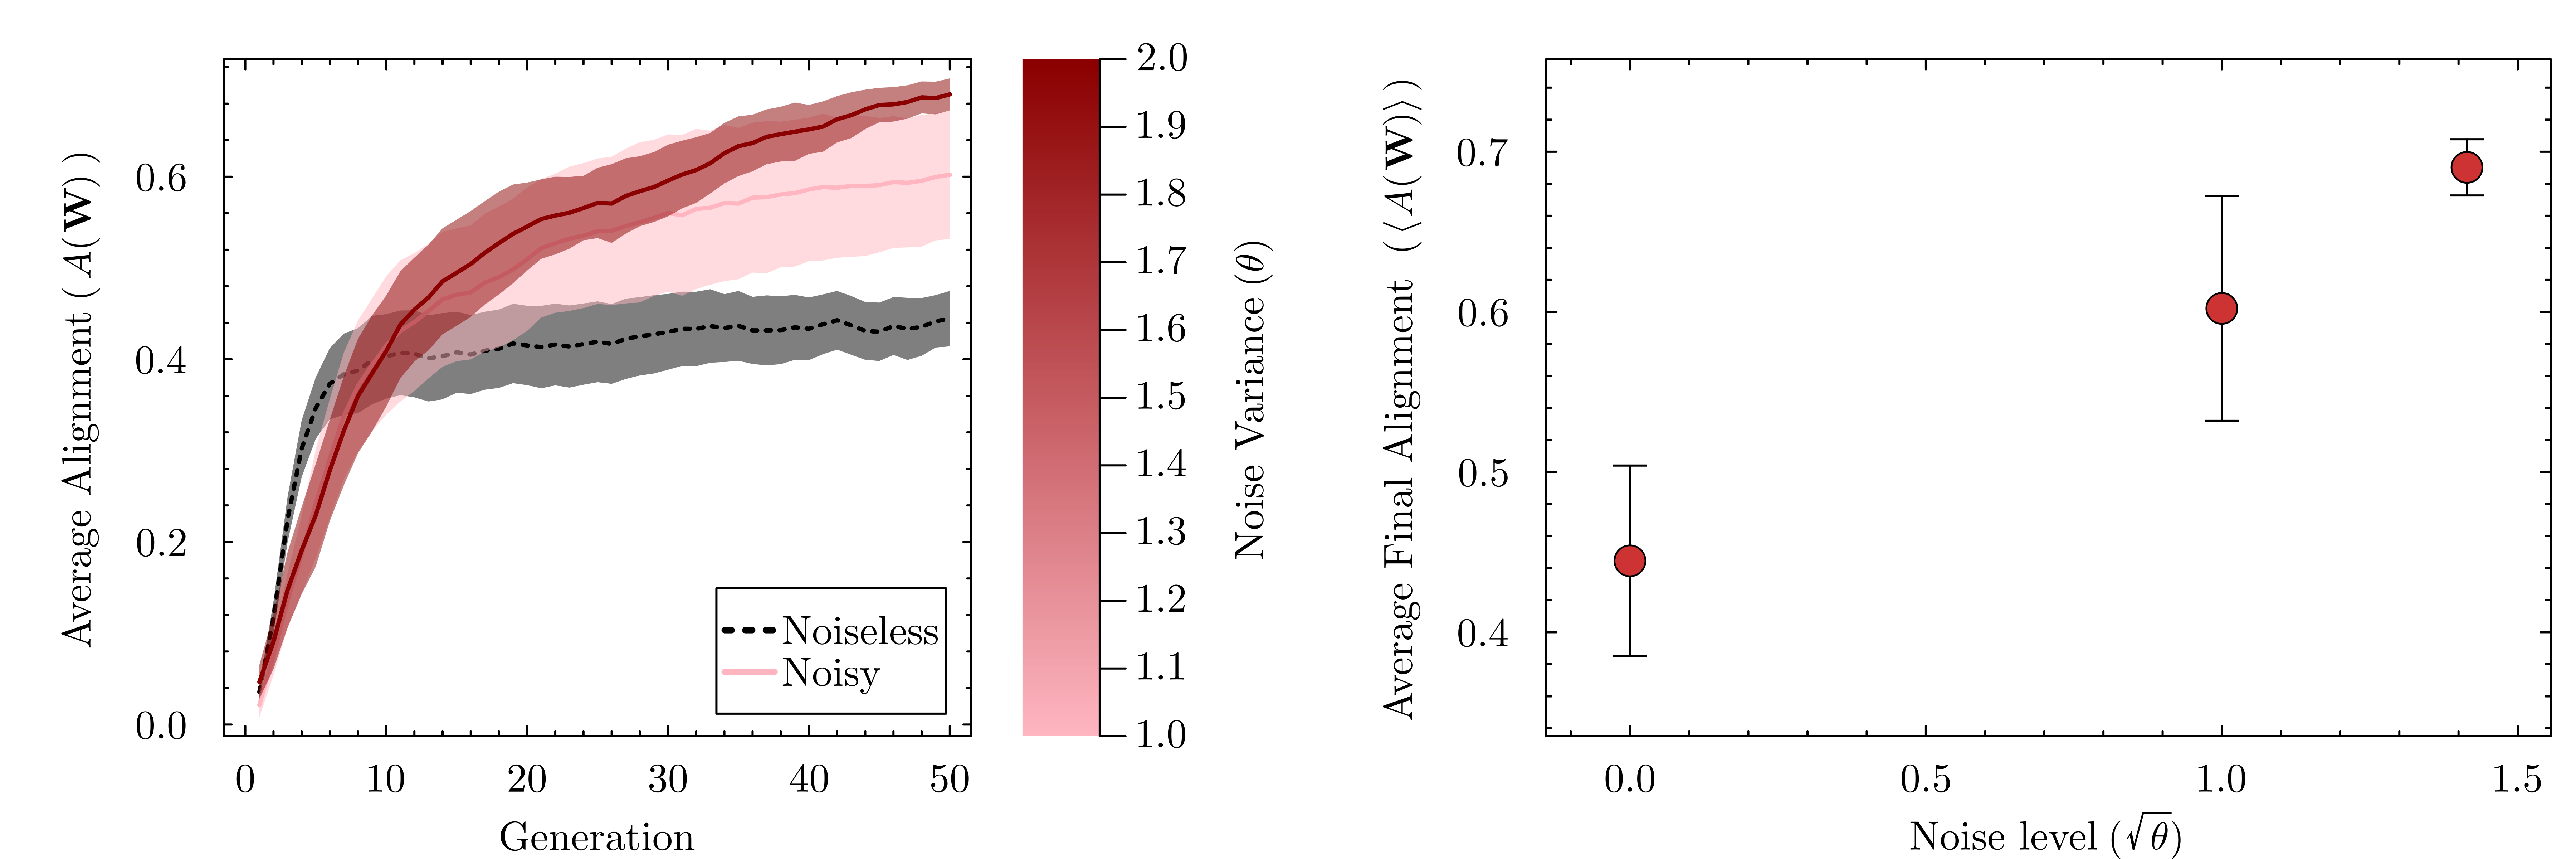

In [15]:
# Figure 4: alignment time series + final alignment scatter.
scatter_final_alignmet = alignment_scatter_plot(exp_1_result)

fig4_combined = plot(plot_avg_alignment, scatter_final_alignmet;
    layout=(1, 2), size=(1200, 400),
    left_margin=12Plots.mm,
    bottom_margin=6Plots.mm, legendfontsize=12, guidefont=12, tickfont=12)

save_plot(fig4_combined, "figure_4_combined.png")
fig4_combined


## Mutational Robustness Scatters


In [16]:
"""Sanitize a string for filenames by replacing non-alphanumerics."""
sanitize_filename(name::String) = replace(lowercase(name), r"[^a-z0-9]+" => "_")

"""
    mutational_scatter_plot(xvals, yvals; xlabel, ylabel, title, xrange=(-0.05, 1.05), yrange=(-0.05, 1.05))

Create a single mutational robustness scatter plot with a diagonal reference line.
"""
function mutational_scatter_plot(
    xvals,
    yvals;
    xlabel::String,
    ylabel::String,
    title::String,
    xrange::Tuple{Float64,Float64}=(-0.05, 1.05),
    yrange::Tuple{Float64,Float64}=(-0.05, 1.05)
)
    plt = scatter(
        xvals,
        yvals;
        xlabel=xlabel,
        ylabel=ylabel,
        color=:darkorange1,
        title=title,
        label="",
        legend=false,
        markersize=6,
        markerstrokewidth = 0.6,
        grid=false,
        left_margin=15Plots.mm,
        bottom_margin=10Plots.mm,
        right_margin = 5Plots.mm,
        xlims=xrange,
        ylims=yrange,
        dpi = 600,
    )
    plot!(
        [xrange[1], xrange[2]],
        [yrange[1], yrange[2]];
        color=:black,
        linestyle=:dash,
        # left_margin=15Plots.mm,
        # bottom_margin=5Plots.mm,
        # right_margin = 5Plots.mm,
        label="",
        grid=false,
    )
    return plt
end

"""Normalize theta in labels to LaTeX-friendly markup."""
normalize_theta(s::String) = replace(replace(s, string(Char(0x03B8)) => L"\theta"), string(Char(0x00CE), Char(0x00B8)) => L"\theta")

"""
    metric_scatter_limits(xvals, yvals; symmetric=false, center=0.0)

Compute dynamic scatter limits from two vectors with a small padding.
For signed metrics, use `symmetric=true` to keep centered axes.
"""
function metric_scatter_limits(xvals, yvals; symmetric::Bool=false, center::Float64=0.0)
    x = Float64.(collect(xvals))
    y = Float64.(collect(yvals))
    vals = vcat(x, y)

    if symmetric
        radius = maximum(abs.(vals .- center))
        pad = max(0.08 * radius, 1e-3)
        return (center - radius - pad, center + radius + pad)
    end

    lo = minimum(vals)
    hi = maximum(vals)
    span = hi - lo
    pad = span > 0 ? 0.08 * span : max(0.1 * max(abs(lo), abs(hi), 1.0), 1e-3)
    return (lo - pad, hi + pad)
end

"""
    handle_mutational_robustness_scatters(result::Experiment1Result)

Generate per-scenario mutational robustness scatters and return a stacked plot.
"""
function handle_mutational_robustness_scatters(result)
    stab_shift_init = result.initial_robustness.stable_expression_shift_population
    stab_shift_final = result.final_robustness.stable_expression_shift_population
    stab_var_init = result.initial_robustness.stable_expression_variance_population
    stab_var_final = result.final_robustness.stable_expression_variance_population
    unstab_shift_init = result.initial_robustness.unstable_probability_shift_population
    unstab_shift_final = result.final_robustness.unstable_probability_shift_population
    unstab_var_init = result.initial_robustness.unstable_probability_variance_population
    unstab_var_final = result.final_robustness.unstable_probability_variance_population

    n = length(result.scenarios)
    all_plots = Vector{Any}(undef, n)

    for idx in eachindex(result.scenarios)
        scenario = result.scenarios[idx]
        label_token = sanitize_filename(scenario.label)
        lab = normalize_theta(scenario.label)

        shift_limits = metric_scatter_limits(stab_shift_init[idx, :], stab_shift_final[idx, :])
        var_limits = metric_scatter_limits(stab_var_init[idx, :], stab_var_final[idx, :])
        unstab_shift_limits = metric_scatter_limits(
            unstab_shift_init[idx, :],
            unstab_shift_final[idx, :];
            symmetric=true,
            center=0.0,
        )
        unstab_var_limits = metric_scatter_limits(unstab_var_init[idx, :], unstab_var_final[idx, :])

        p1 = mutational_scatter_plot(
            stab_shift_init[idx, :],
            stab_shift_final[idx, :];
            xlabel="Before Evolution",
            ylabel="After Evolution",
            title="Stable Expression Shift $lab "*L"\langle \Delta \bar{v} \,( 𝐖 ) \rangle",
            xrange=shift_limits,
            yrange=shift_limits,
        )

        p2 = mutational_scatter_plot(
            stab_var_init[idx, :],
            stab_var_final[idx, :];
            xlabel="Before Evoltuion",
            ylabel="After Evolution",
            title="Stable Expression Variance $lab " * L"\langle \sigma^2( 𝐖 ) \rangle",
            xrange=var_limits,
            yrange=var_limits,
        )

        p3 = mutational_scatter_plot(
            unstab_shift_init[idx, :],
            unstab_shift_final[idx, :];
            xlabel="Before Evolution",
            ylabel="After Evolution",
            title="Unstable Probability Shift $lab " * L"\langle p_u( 𝐖 ) \rangle",
            xrange=unstab_shift_limits,
            yrange=unstab_shift_limits,
        )

        p4 = mutational_scatter_plot(
            unstab_var_init[idx, :],
            unstab_var_final[idx, :];
            xlabel="Before Evolution",
            ylabel="After Evolution",
            title="Unstable Probability Variance $lab " * L"\langle \rho^2(𝐖) \rangle",
            xrange=unstab_var_limits,
            yrange=unstab_var_limits,
        )

        combined = plot(p1, p2, p3, p4; layout=(2, 2), size=(1150, 800), grid=false)
        savefig(combined, joinpath(ROBUSTNESS_FIG_DIR, "robustness_$(label_token).png"))
        all_plots[idx] = combined
    end

    # return plot(all_plots...; layout=(n, 1), size=(1150, 820n),
    #     left_margin=5Plots.mm, bottom_margin=5Plots.mm, right_margin = 5Plots.mm)
    return all_plots
end


handle_mutational_robustness_scatters

In [17]:
# Figure set: mutational robustness scatter grids.
all_plots = handle_mutational_robustness_scatters(exp_1_result)

for figure_plotted in all_plots
    display(figure_plotted)
    save_plot(figure_plotted, "scatterplots_mutational_robustness/theta=$(exp_1.)")
end
# save_plot(all_plots, "scatterplots_mutational_robustness/combined.png")
# display(all_plots)

LoadError: ParseError:
[90m# Error @ [0;0m]8;;file://c:/Users/Kichi/Documents/Documentos_and_Stuff/Academic Projects/SFI GRNs/WagnerNoiseExtension/wagner-noise-extension/notebooks/In[17]#6:81\[90mIn[17]:6:81[0;0m]8;;\
    display(figure_plotted)
    save_plot(figure_plotted, "scatterplots_mutational_robustness/theta=$(exp_1.[48;2;120;70;70m)[0;0m")
[90m#                                                                               ╙ ── [0;0m[91munexpected `)`[0;0m

## Mutational Robustness vs Noise


In [ ]:
"""
    initial_vs_final_mutational_robustness(result::Experiment1Result)

Compare initial vs final robustness changes across noise levels.
"""
function initial_vs_final_mutational_robustness(result)
    stab_shift_init = result.initial_robustness.stable_expression_shift_population
    stab_shift_final = result.final_robustness.stable_expression_shift_population
    stab_var_init = result.initial_robustness.stable_expression_variance_population
    stab_var_final = result.final_robustness.stable_expression_variance_population
    unstab_shift_init = result.initial_robustness.unstable_probability_shift_population
    unstab_shift_final = result.final_robustness.unstable_probability_shift_population
    unstab_var_init = result.initial_robustness.unstable_probability_variance_population
    unstab_var_final = result.final_robustness.unstable_probability_variance_population

    theta_vals = [scenario.variance for scenario in result.scenarios]
    x = sqrt.(theta_vals)

    function summarize_deltas(initial_metric, final_metric)
        delta_mean = Float64[]
        delta_ci = Float64[]
        for idx in eachindex(result.scenarios)
            delta = final_metric[idx, :] .- initial_metric[idx, :]
            push!(delta_mean, mean(delta))
            push!(delta_ci, 1.96 * std(delta) / sqrt(length(delta)))
        end
        return delta_mean, delta_ci
    end

    common_kwargs = (
        legend=false,
        grid=false,
        minorgrid=false,
        marker=:circle,
        color=:darkorange1,
        markersize=7,
        markerstrokewidth=1,
        errorbarlinewidth=2,
        errorbarcapsize=4,
        linecolor=:black,
        dpi=600,
    )

    shift_delta, shift_ci = summarize_deltas(stab_shift_init, stab_shift_final)
    stab_shift_vs_theta = scatter(
        x,
        shift_delta;
        xlabel="Noise level " * L"(\sqrt{\theta})",
        ylabel="Change in " * L"\langle \Delta \bar{v} \, (𝐖) \rangle",
        yerror=shift_ci,
        common_kwargs...,
    )
    # hline!(stab_shift_vs_theta, [0.0]; color=:black, linestyle=:dash, linewidth=1, label="")

    stab_var_delta, stab_var_ci = summarize_deltas(stab_var_init, stab_var_final)
    stab_var_vs_theta = scatter(
        x,
        stab_var_delta;
        xlabel="Noise level " * L"(\sqrt{\theta})",
        ylabel="Change in " *L"\langle \sigma^2 (𝐖)\rangle",
        yerror=stab_var_ci,
        common_kwargs...,
    )
    # hline!(stab_var_vs_theta, [0.0]; color=:black, linestyle=:dash, linewidth=1, label="")

    unstab_shift_delta, unstab_shift_ci = summarize_deltas(unstab_shift_init, unstab_shift_final)
    unstab_shift_vs_theta = scatter(
        x,
        unstab_shift_delta;
        xlabel="Noise level " * L"(\sqrt{\theta})",
        ylabel="Change in " * L"\langle p_u (𝐖) \rangle",
        yerror=unstab_shift_ci,
        ylims=(minimum(unstab_shift_delta) - 0.005, 0.005),
        common_kwargs...,
    )
    hline!(unstab_shift_vs_theta, [0.0]; color=:black, linestyle=:dash, linewidth=1, label="")

    unstab_var_delta, unstab_var_ci = summarize_deltas(unstab_var_init, unstab_var_final)
    unstab_var_vs_theta = scatter(
        x,
        unstab_var_delta;
        xlabel="Noise level " * L"(\sqrt{\theta})",
        ylabel="Change in " * L"\langle \rho^2 (𝐖) \rangle",
        yerror=unstab_var_ci,
        common_kwargs...,
    )
    hline!(unstab_var_vs_theta, [0.0]; color=:black, linestyle=:dash, linewidth=1, label="")

    savefig(stab_shift_vs_theta, joinpath(ROBUSTNESS_FIG_DIR, "stable_expression_shift_vs_theta.png"))
    savefig(stab_var_vs_theta, joinpath(ROBUSTNESS_FIG_DIR, "stable_expression_variance_vs_theta.png"))
    savefig(unstab_shift_vs_theta, joinpath(ROBUSTNESS_FIG_DIR, "unstable_probability_shift_vs_theta.png"))
    savefig(unstab_var_vs_theta, joinpath(ROBUSTNESS_FIG_DIR, "unstable_probability_variance_vs_theta.png"))

    return stab_shift_vs_theta, stab_var_vs_theta, unstab_shift_vs_theta, unstab_var_vs_theta
end


initial_vs_final_mutational_robustness

Saved c:\Users\Kichi\Documents\Documentos_and_Stuff\Academic Projects\SFI GRNs\WagnerNoiseExtension\wagner-noise-extension\figures\scatterplots_mutational_robustness/deltas_vs_theta.png


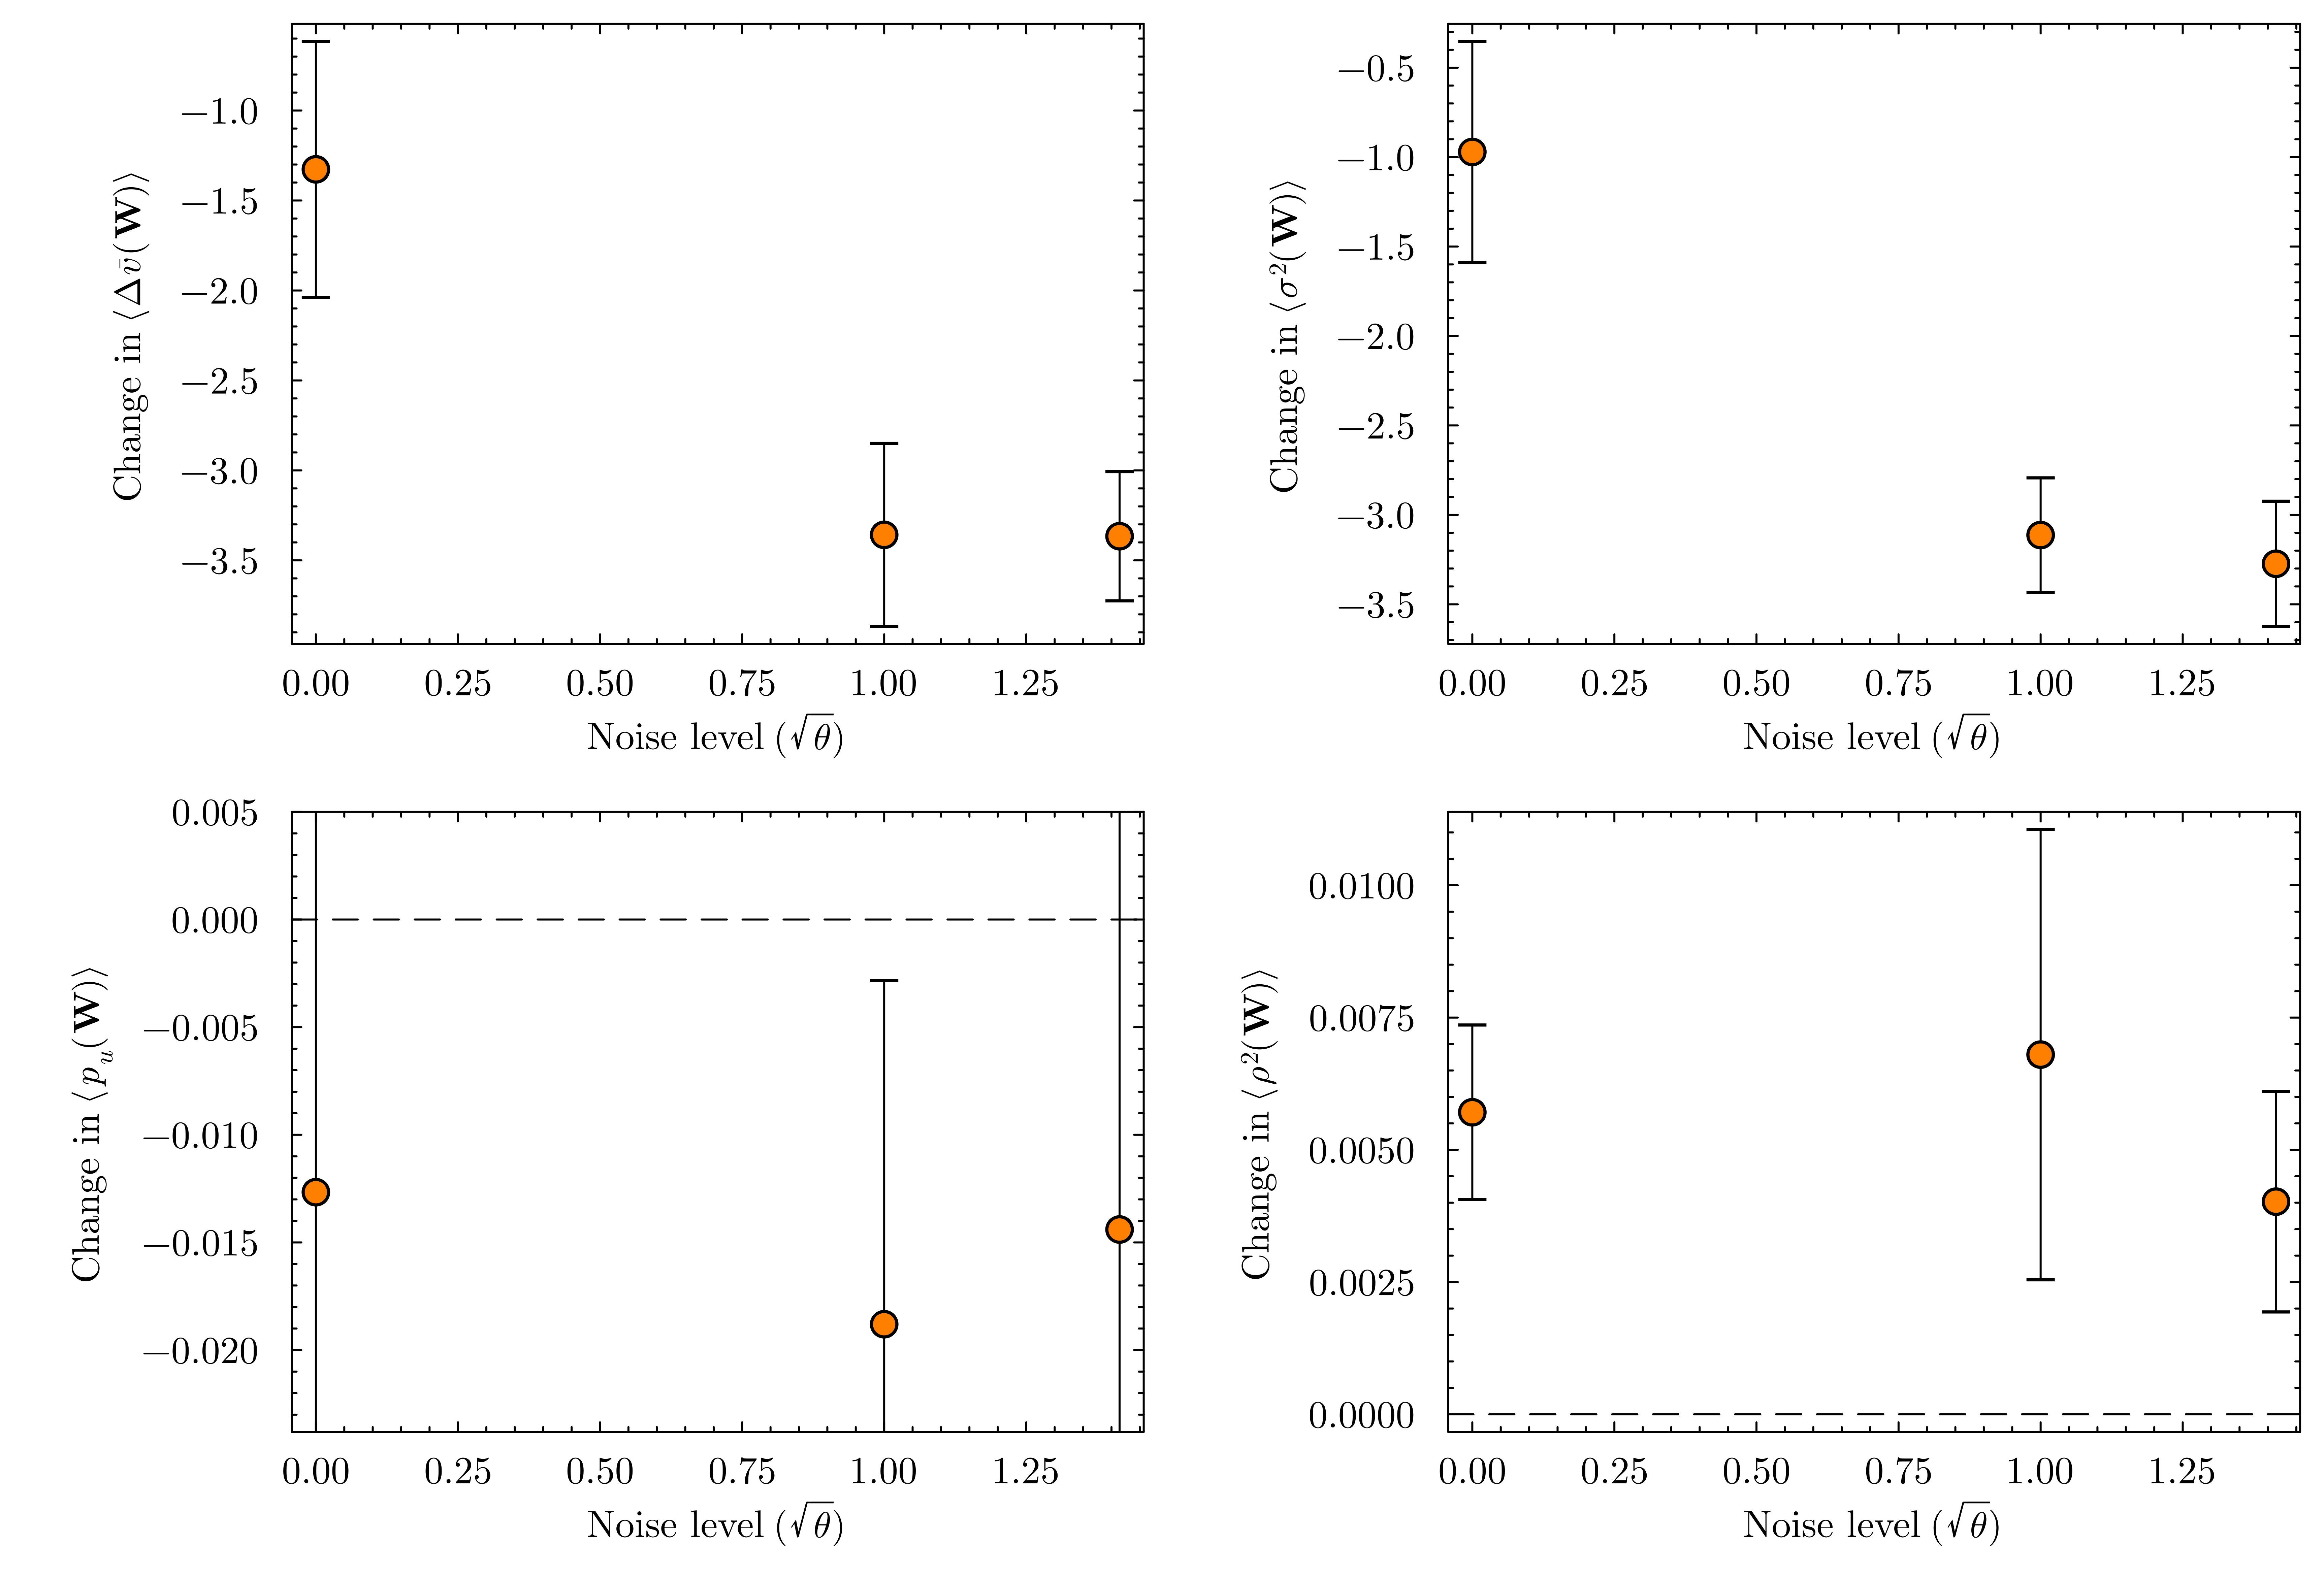

In [ ]:
# Figure set: robustness deltas vs noise.
stab_shift_vs_theta, stab_var_vs_theta, unstab_shift_vs_theta, unstab_var_vs_theta = initial_vs_final_mutational_robustness(exp_1_result)

robustness_deltas = plot(
    stab_shift_vs_theta,
    stab_var_vs_theta,
    unstab_shift_vs_theta,
    unstab_var_vs_theta;
    layout=(2, 2),
    size=(1150, 780),
    left_margin=12Plots.mm,
    bottom_margin=5Plots.mm,
    legendfontsize=12,
    guidefont=12,
    tickfont=12,
    dpi=600,
)

save_plot(robustness_deltas, "scatterplots_mutational_robustness/deltas_vs_theta.png")
display(robustness_deltas)


## Experiment 1: Statistical Tests


In [ ]:
"""
    handle_alignment_tests(result::Experiment1Result; bonferroni_factor::Int=1)

Run Welch's t-test comparing noiseless vs noisy final alignment.
"""
function handle_alignment_tests(result; bonferroni_factor::Int=1)
    noiseless = result.final_alignments[1, :]
    noisy = vec(result.final_alignments[2:end, :])
    test = UnequalVarianceTTest(noiseless, noisy)
    println("
Welch's t-test (noiseless vs noisy final alignment)")
    println(test)
    raw_p = pvalue(test)
    corrected_p = min(raw_p * bonferroni_factor, 1.0)
    println("p-value: $(raw_p)")
    if bonferroni_factor > 1
        println("Bonferroni-corrected p-value (x$(bonferroni_factor)): $(corrected_p)")
    end
end


handle_alignment_tests

In [ ]:
handle_alignment_tests(exp_1_result; bonferroni_factor=BONFERRONI_TESTS)



Welch's t-test (noiseless vs noisy final alignment)
Two sample t-test (unequal variance)
------------------------------------
Population details:
    parameter of interest:   Mean difference
    value under h_0:         0
    point estimate:          -0.253696
    95% confidence interval: (-0.321, -0.1864)

Test summary:
    outcome with 95% confidence: reject h_0
    two-sided p-value:           <1e-05

Details:
    number of observations:   [10,20]
    t-statistic:              -8.213566377024485
    degrees of freedom:       11.970442086362734
    empirical standard error: 0.030887460130222633

p-value: 2.915538843516404e-6
Bonferroni-corrected p-value (x2): 5.831077687032808e-6


# Experiment 2: Motif Summary Plots


In [ ]:
# Summary helper
"""
    summarize_expectations(data::Dict{K,Vector{Float64}}) where {K}

Return mean and standard error for each category.
"""
function summarize_expectations(data::Dict{K,Vector{Float64}}) where {K}
    return Dict(k => (mean(v), std(v) / sqrt(length(v))) for (k, v) in data)
end

"""
    create_summary_plots(data_dict, null_expectation; title="", data_label="Data", null_label="Null")

Create the FFL average +/- 95% CI summary panel.
X ticks are hidden so motif images can be overlaid later.
"""
function create_summary_plots(data_dict::Dict{String, Vector{Float64}},
        null_expectation::Dict{String, Tuple{Float64, Float64}};
        title::String="",
        data_label::String="Data",
        null_label::String="Null")

    sorted_keys = sort(collect(keys(data_dict)))
    means = [mean(data_dict[k]) for k in sorted_keys]
    ses = [std(data_dict[k]) / sqrt(length(data_dict[k])) for k in sorted_keys]

    null_means = [get(null_expectation, k, (0.0, 0.0))[1] for k in sorted_keys]
    null_ses = [get(null_expectation, k, (0.0, 0.0))[2] for k in sorted_keys]

    is_incoherent(k) = occursin("incoherent", lowercase(k))
    is_coherent(k) = occursin("coherent", lowercase(k)) && !is_incoherent(k)

    colors = [is_incoherent(k) ? :red : :blue for k in sorted_keys]
    null_colors = [is_incoherent(k) ? :pink : :lightblue2 for k in sorted_keys]

    x_vals = collect(1:length(sorted_keys))
    dx = 0.20
    x_data = x_vals .- dx
    x_null = x_vals .+ dx

    p_left = scatter(
        x_data,
        means;
        # xticks=false,
        minorticks = false,
        xticks=(x_data, fill("", length(x_data))),
        yerror=ses .* 1.96,
        markersize=8,
        markerstrokewidth=1,
        color=colors,
        label=data_label,
        xlabel="",
        ylabel="Concentration (%)",
        title=title,
        legend=:topright,
        grid=false,
        minorgrid=false,
        left_margin=12Plots.mm,
        bottom_margin=12Plots.mm,
        errorbarcolor=:black,
        errorbarlinewidth=2,
        xlims=(0.3, length(sorted_keys) + 0.7),
        dpi=600,
    )

    scatter!(
        p_left,
        x_null,
        null_means;
        yerror=null_ses .* 1.96,
        marker=:hexagon,
        markersize=6,
        label=null_label,
        color=null_colors,
        errorbarcolor=null_colors,
        errorbarlinewidth=2,
        errorbarcap=:round,
        markerstrokewidth=0.8,
    )


    return p_left
end

"""
    create_summary_plots_fbcks(expectations_primary_reinf, expectations_reference_reinf,
                               expectations_primary_balanc, expectations_reference_balanc,
                               title; max_size=4, ...)

Create a feedback-loop panel with reinforcing concentrations on the left y-axis
and balancing concentrations on the right y-axis.
"""
function create_summary_plots_fbcks(expectations_primary_reinf::Dict{Int,Tuple{Float64,Float64}},
    expectations_reference_reinf::Dict{Int,Tuple{Float64,Float64}},
    expectations_primary_balanc::Dict{Int,Tuple{Float64,Float64}},
    expectations_reference_balanc::Dict{Int,Tuple{Float64,Float64}},
    title::String;
    max_size::Int=4,
    color=:blue,
    null_color=:lightblue2,
    reference_label::String="Reference",
    primary_label::String="Primary")

    sizes = collect(1:max_size)
    dx = 0.10

    mean_primary_reinf = [get(expectations_primary_reinf, s, (0.0, 0.0))[1] for s in sizes]
    sem_primary_reinf = [get(expectations_primary_reinf, s, (0.0, 0.0))[2] for s in sizes]
    mean_reference_reinf = [get(expectations_reference_reinf, s, (0.0, 0.0))[1] for s in sizes]
    sem_reference_reinf = [get(expectations_reference_reinf, s, (0.0, 0.0))[2] for s in sizes]

    mean_primary_balanc = [get(expectations_primary_balanc, s, (0.0, 0.0))[1] for s in sizes]
    sem_primary_balanc = [get(expectations_primary_balanc, s, (0.0, 0.0))[2] for s in sizes]
    mean_reference_balanc = [get(expectations_reference_balanc, s, (0.0, 0.0))[1] for s in sizes]
    sem_reference_balanc = [get(expectations_reference_balanc, s, (0.0, 0.0))[2] for s in sizes]

    lower_reinf = min.(mean_primary_reinf .- 1.96 .* sem_primary_reinf,
                       mean_reference_reinf .- 1.96 .* sem_reference_reinf)
    upper_reinf = max.(mean_primary_reinf .+ 1.96 .* sem_primary_reinf,
                       mean_reference_reinf .+ 1.96 .* sem_reference_reinf)
    min_reinf = minimum(lower_reinf)
    max_reinf = maximum(upper_reinf)
    pad_reinf = max(0.05, 0.1 * (max_reinf - min_reinf))
    ymin_reinf = clamp(min_reinf - pad_reinf, 0.0, 1.0)
    ymax_reinf = clamp(max_reinf + pad_reinf, 0.0, 1.0)

    lower_balanc = min.(mean_primary_balanc .- 1.96 .* sem_primary_balanc,
                        mean_reference_balanc .- 1.96 .* sem_reference_balanc)
    upper_balanc = max.(mean_primary_balanc .+ 1.96 .* sem_primary_balanc,
                        mean_reference_balanc .+ 1.96 .* sem_reference_balanc)
    min_balanc = minimum(lower_balanc)
    max_balanc = maximum(upper_balanc)
    pad_balanc = max(0.05, 0.1 * (max_balanc - min_balanc))
    ymin_balanc = clamp(min_balanc - pad_balanc, 0.0, 1.0)
    ymax_balanc = clamp(max_balanc + pad_balanc, 0.0, 1.0)

    plt = plot(
        sizes .- dx,
        mean_primary_reinf;
        seriestype=:scatter,
        yerror=sem_primary_reinf .* 1.96,
        marker=:circle,
        markersize=8,
        color="#5cbf8a",
        label="$(primary_label), Positive",
        errorbarcolor=color,
        errorbarlinewidth=2,
        errorbarcap=:round,
        markerstrokewidth=1,
        minorgrid=false,
        minorticks=false,
    )

    scatter!(
        plt,
        sizes .- dx,
        mean_primary_balanc;
        yerror=sem_primary_balanc .* 1.96,
        marker=:utriangle,
        markersize=7,
        markerstrokewidth=1,
        color="#e94e77",
        label="$(primary_label), Negative",
        errorbarcolor="#e94e77",
        errorbarlinewidth=2,
        errorbarcap=:round,
    )

    scatter!(
        plt,
        sizes .+ dx,
        mean_reference_reinf;
        yerror=sem_reference_reinf .* 1.96,
        marker=:hexagon,
        markersize=6,
        markerstrokewidth=0.8,
        color="#8cd5a0",
        label="$(reference_label), Positive",
        xticks=(sizes, string.(sizes)),
        xlabel="Feedback-loop size",
        ylabel="Concentration (%)",
        title=title,
        # ylim=(ymin_reinf, ymax_reinf),
        xlims=(0.5, max_size + 0.5),
        left_margin=10Plots.mm,
        right_margin=10Plots.mm,
        bottom_margin=8Plots.mm,
        legend=:best,
        errorbarcolor=:black,
        errorbarlinewidth=2,
        errorbarcap=:round,
        grid=false,
        minorgrid=false,
        minorticks=false,
        dpi=600,
    )

    scatter!(
        plt,
        sizes .+ dx,
        mean_reference_balanc;
        yerror=sem_reference_balanc .* 1.96,
        marker=:diamond,
        markersize=6,
        markerstrokewidth=0.8,
        color="#f1a7c1",
        xticks=(sizes, string.(sizes)),
        label="$(reference_label), Negative",
        ylim=(upper_reinf, lower_reinf),
        xlims=(0.5, max_size + 0.5),
        errorbarcolor="#f1a7c1",
        errorbarlinewidth=2,
        errorbarcap=:round,
        grid=false,
        minorgrid=false,
        minorticks=false,
    )

    return plt
end

"""
    handle_noiseless_vs_random(result::Experiment2Result)

Generate the comparison plot with only:
1) FFL average +/- SE panel, and
2) Positive feedback concentration panel.
"""
function handle_noiseless_vs_random(result)
    expect_random = summarize_expectations(result.random.ffl)

    expect_random_reinf = summarize_expectations(result.random.fbcks_reinf)
    expect_noiseless_reinf = summarize_expectations(result.noiseless.fbcks_reinf)
    expect_random_balanc = summarize_expectations(result.random.fbcks_balanc)
    expect_noiseless_balanc = summarize_expectations(result.noiseless.fbcks_balanc)

    max_size = result.config.max_loop_size

    noiseless_ffl_left = create_summary_plots(
        result.noiseless.ffl,
        expect_random;
        null_label="Random",
        data_label="Noiseless",
        title = "Feedforward Loop Concentrations"
    )

    noiseless_reinf = create_summary_plots_fbcks(
        expect_noiseless_reinf,
        expect_random_reinf,
        expect_noiseless_balanc,
        expect_random_balanc,
        "Feedback Loop Concentrations";
        max_size=max_size,
        color=:blue,
        null_color=:lightblue2,
        reference_label="Random",
        primary_label="Noiseless",
    )

    plot_noiseless = plot(
        noiseless_ffl_left,
        noiseless_reinf;
        layout=(1, 2),
        size=(1100, 430),
        suptitle="Random vs Noiseless",
    )

    return plot_noiseless
end


handle_noiseless_vs_random

Saved c:\Users\Kichi\Documents\Documentos_and_Stuff\Academic Projects\SFI GRNs\WagnerNoiseExtension\wagner-noise-extension\figures\noiseless_vs_random_stable.png


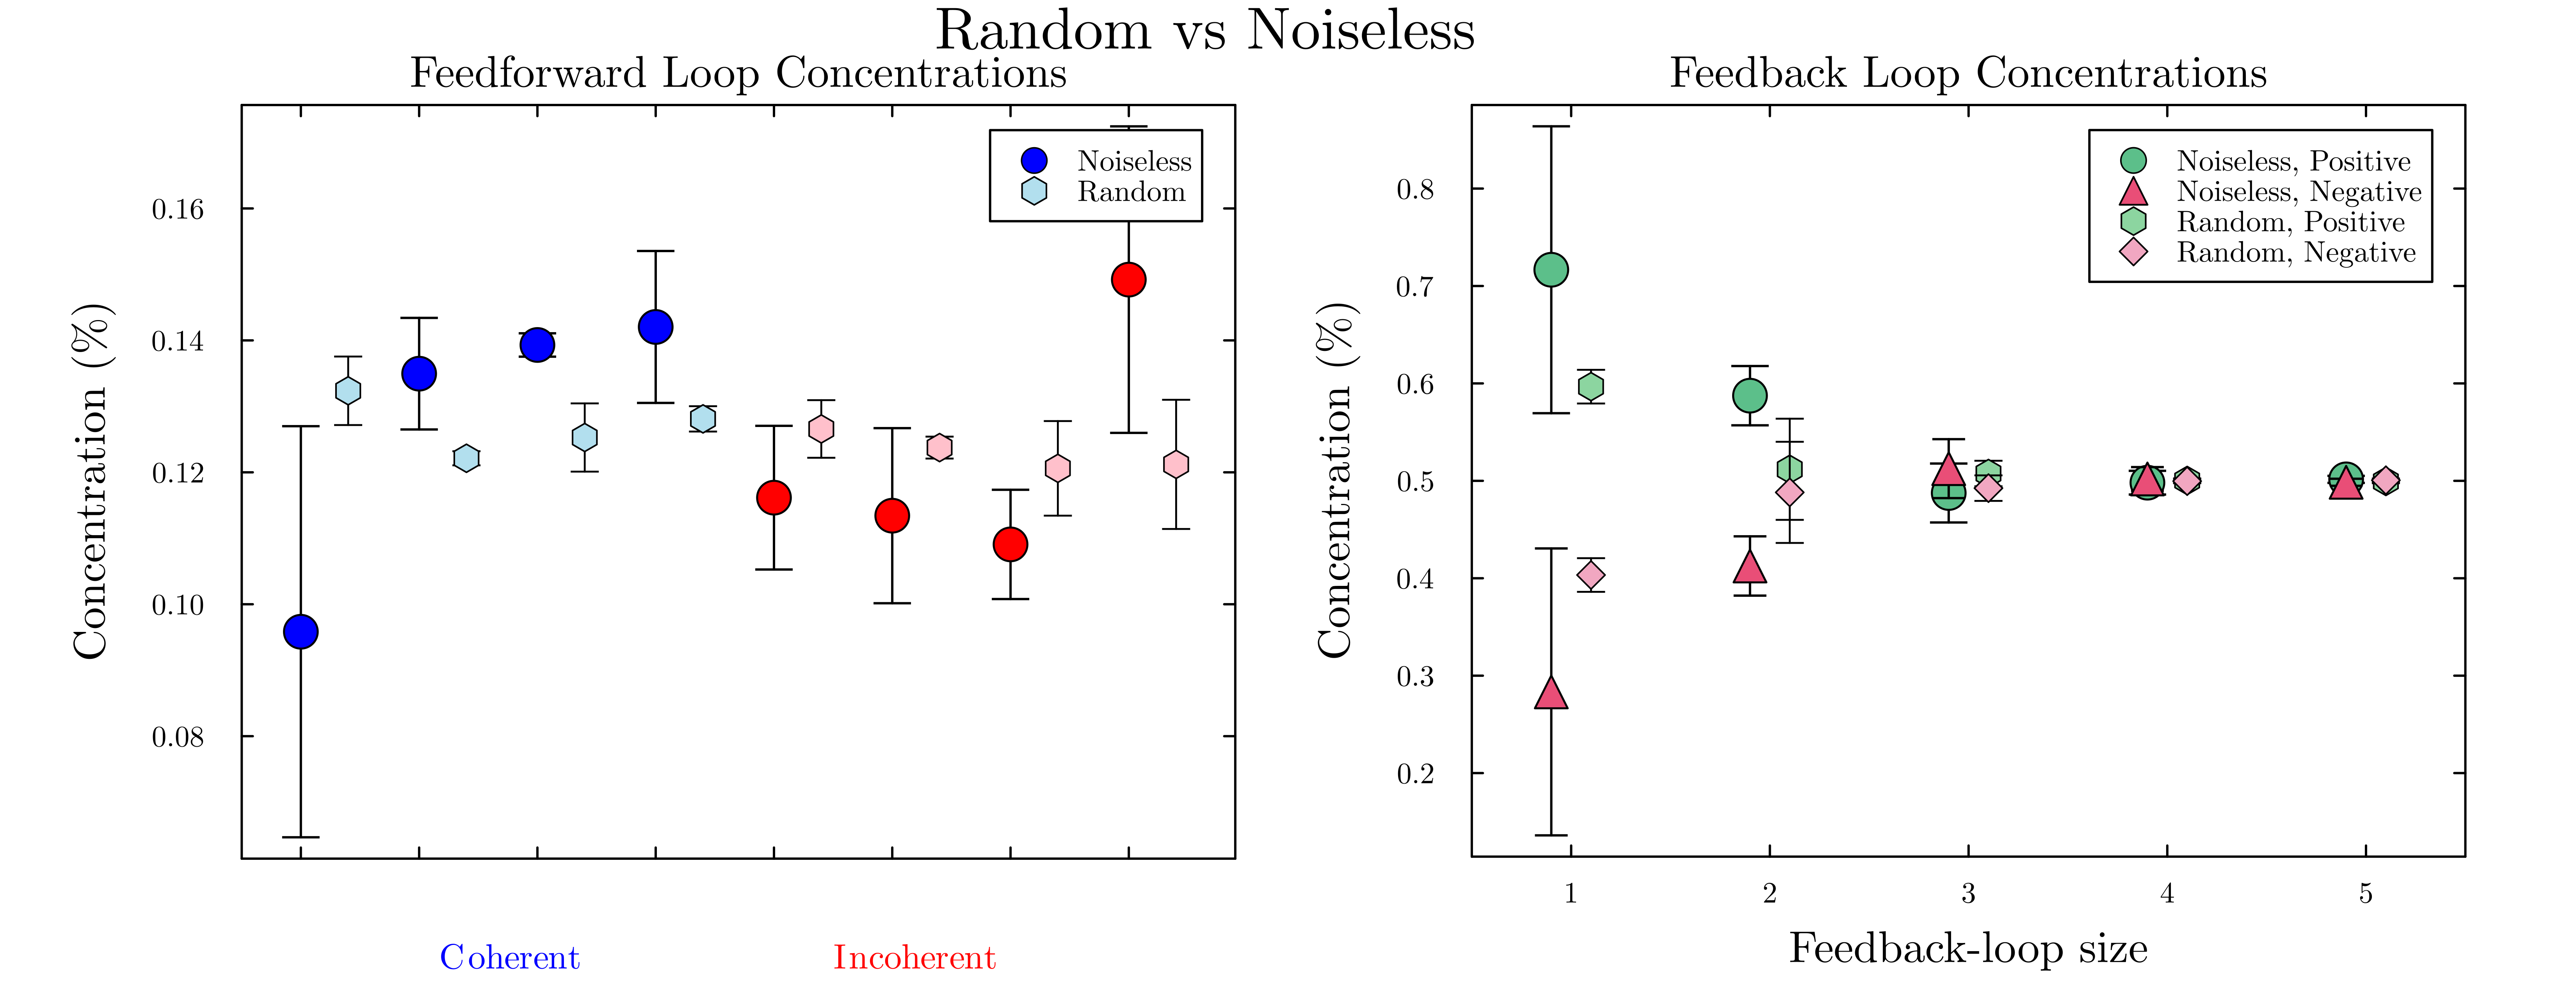

In [ ]:
using Logging
Logging.disable_logging(Logging.Warn)
# Warnings at or below the Warning level will be suppressed globally.
@warn "You won't see this"
mode_tag = lowercase(replace(exp_1_result.config.mode, " " => "_"))

fig5_combined = handle_noiseless_vs_random(exp_2_result)

annotate!(fig5_combined, .14, -18, text(L"\mathrm{Coherent}", 10, :Blue))
annotate!(fig5_combined, 0.35, -18, text(L"\mathrm{Incoherent}", 10, :Red))

save_plot(fig5_combined, "noiseless_vs_random_$(mode_tag).png")
fig5_combined



## Figure 6: High Noise vs Noiseless


In [ ]:
"""
    handle_high_noise_vs_noiseless(result::Experiment2Result)

Generate the comparison plot with only:
1) FFL average +/- SE panel, and
2) Positive feedback concentration panel.
"""
function handle_high_noise_vs_noiseless(result)
    expect_noiseless = summarize_expectations(result.noiseless.ffl)

    expect_noiseless_reinf = summarize_expectations(result.noiseless.fbcks_reinf)
    expect_noisy_reinf = summarize_expectations(result.noisy.fbcks_reinf)
    expect_noiseless_balanc = summarize_expectations(result.noiseless.fbcks_balanc)
    expect_noisy_balanc = summarize_expectations(result.noisy.fbcks_balanc)

    max_size = result.config.max_loop_size

    noisy_ffl_left = create_summary_plots(
        result.noisy.ffl,
        expect_noiseless;
        null_label="Noiseless",
        data_label="Very Noisy",
        title = "Feedforward Loop Concentration"
    )

    noisy_reinf = create_summary_plots_fbcks(
        expect_noisy_reinf,
        expect_noiseless_reinf,
        expect_noisy_balanc,
        expect_noiseless_balanc,
        "Feedback Loop Concentration";
        max_size=max_size,
        reference_label="Noiseless",
        primary_label="Very Noisy",
    )

    combined_plot = plot(
        noisy_ffl_left,
        noisy_reinf;
        layout=(1, 2),
        size=(1100, 430),
        suptitle="Very Noisy vs Noiseless",
    )

    return combined_plot
end


handle_high_noise_vs_noiseless

Saved c:\Users\Kichi\Documents\Documentos_and_Stuff\Academic Projects\SFI GRNs\WagnerNoiseExtension\wagner-noise-extension\figures\high_noise_vs_noiseless_stable.png


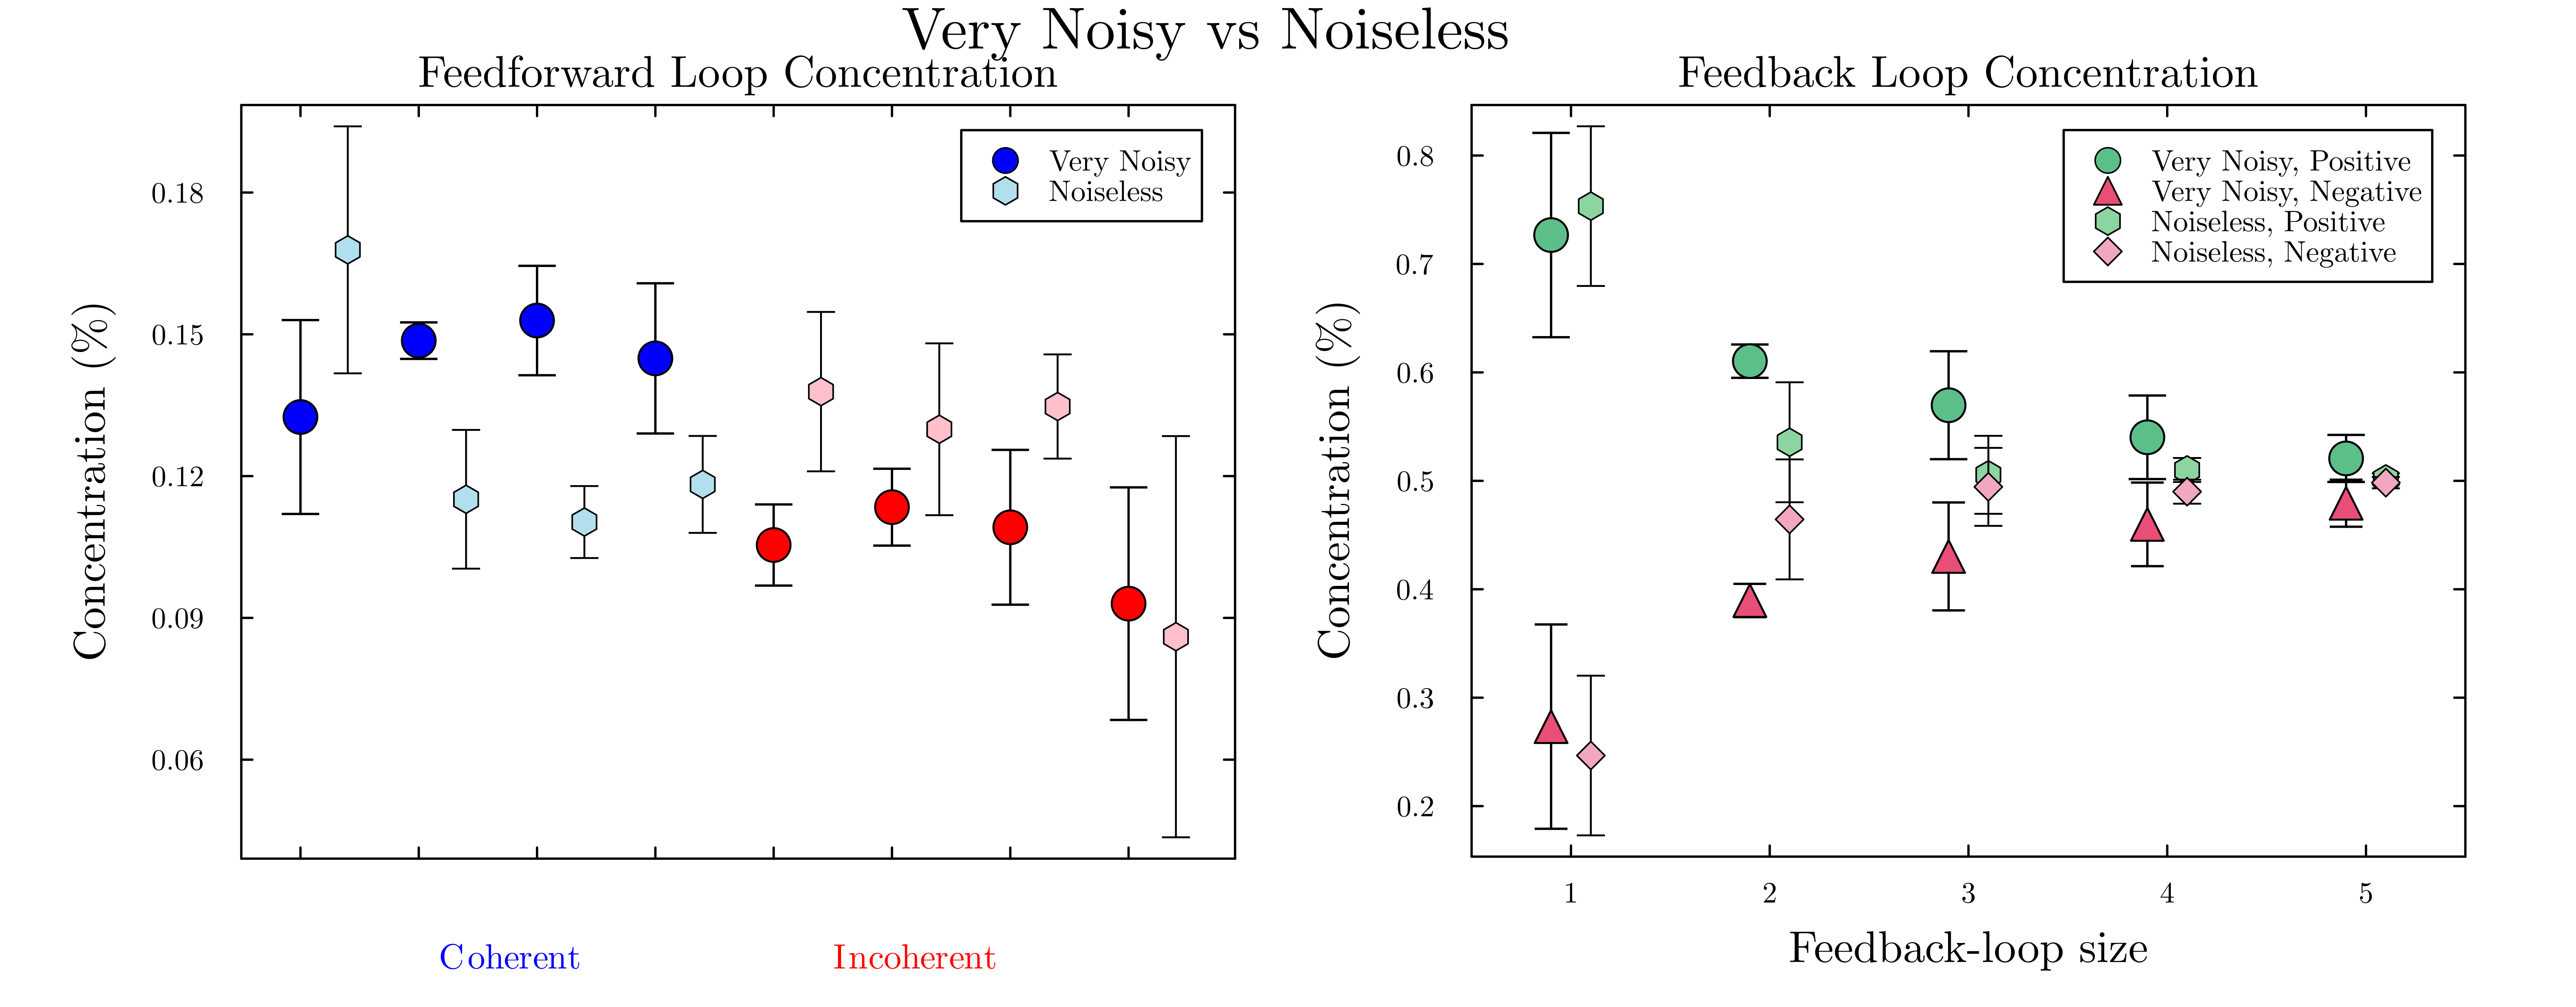

In [ ]:
# Figure 6: high noise vs noiseless.
fig6_combined = handle_high_noise_vs_noiseless(exp2_result)

annotate!(fig6_combined, 0.14, -18, text(L"\mathrm{Coherent}", 10, :Blue))
annotate!(fig6_combined, 0.35, -18, text(L"\mathrm{Incoherent}", 10, :Red))

save_plot(fig6_combined, "high_noise_vs_noiseless_$(mode_tag).png")
fig6_combined


## Experiment 2: Statistical Tests


In [ ]:
"""
    coherent_fraction_samples(stats::MotifStats)

Aggregate coherent FFL fractions across trials.
"""
function coherent_fraction_samples(stats::MotifStats)
    if isempty(stats.ffl)
        return zeros(Float64, 0)
    end
    trials = length(first(values(stats.ffl)))
    samples = zeros(Float64, trials)
    for (key, values) in stats.ffl
        if occursin("Coherent", key)
            samples .+= values
        end
    end
    return samples
end

"""
    handle_motif_welch_tests(result::Experiment2Result; bonferroni_factor::Int=1)

Run Welch's tests on motif coherence across scenarios.
"""
function handle_motif_welch_tests(result; bonferroni_factor::Int=1)
    noisy_samples = coherent_fraction_samples(result.noisy)
    noiseless_samples = coherent_fraction_samples(result.noiseless)
    random_samples = coherent_fraction_samples(result.random)

    println("Non-evolved coherence: $(mean(random_samples))")
    println("Noiseless coherence: $(mean(noiseless_samples))")
    println("Noisy coherence: $(mean(noisy_samples))")

    if isempty(noiseless_samples) || isempty(random_samples)
        println("Insufficient motif samples to run Welch's test.")
        return
    end
    test1 = UnequalVarianceTTest(noiseless_samples, random_samples)
    println("
Welch's t-test (noiseless vs random coherent FFL concentration)")
    println(test1)
    raw_p = pvalue(test1)
    corrected_p = min(raw_p * bonferroni_factor, 1.0)
    println("p-value: $(raw_p)")
    if bonferroni_factor > 1
        println("Bonferroni-corrected p-value (x$(bonferroni_factor)): $(corrected_p)")
    end

    test2 = UnequalVarianceTTest(noisy_samples, noiseless_samples)
    println("
Welch's t-test (very noisy vs noiseless coherent FFL concentration)")
    println(test2)
    raw_p = pvalue(test2)
    corrected_p = min(raw_p * bonferroni_factor, 1.0)
    println("p-value: $(raw_p)")
    if bonferroni_factor > 1
        println("Bonferroni-corrected p-value (x$(bonferroni_factor)): $(corrected_p)")
    end
end


handle_motif_welch_tests

In [ ]:
handle_motif_welch_tests(exp2_result; bonferroni_factor=BONFERRONI_TESTS)


Non-evolved coherence: 0.5044444444444445
Noiseless coherence: 0.5114814814814815
Noisy coherence: 0.5789814814814814

Welch's t-test (noiseless vs random coherent FFL concentration)
Two sample t-test (unequal variance)
------------------------------------
Population details:
    parameter of interest:   Mean difference
    value under h_0:         0
    point estimate:          0.00703704
    95% confidence interval: (-0.01759, 0.03166)

Test summary:
    outcome with 95% confidence: fail to reject h_0
    two-sided p-value:           0.4024

Details:
    number of observations:   [3,3]
    t-statistic:              0.9976709047522708
    degrees of freedom:       2.58601894619995
    empirical standard error: 0.007053465229382843

p-value: 0.40244001865546164
Bonferroni-corrected p-value (x2): 0.8048800373109233

Welch's t-test (very noisy vs noiseless coherent FFL concentration)
Two sample t-test (unequal variance)
------------------------------------
Population details:
    paramet